In [752]:
# imports and plotting defaults
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from long_term_wear_plotting import (
    mask_to_segments,
    merge_close_segments,
    drop_tiny_segments,
    plot_group,
    plot_all_signals_one_figure,
    keep_min_duration_segments,
    add_wrist_flex_ext_from_imus,
    extract_calibration_segments_from_notes,
    build_adc_calibration_table,
    build_adc_calibration_table_from_spec,
    fit_adc_angle_models,
    summarize_adc_angle_models,
    apply_adc_angle_models,
    plot_adc_calibration_models,
    plot_adc_calibration_models_with_raw,
    plot_calibration_sets_by_sensor,
)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = False

In [753]:
# fixed display settings
adc_ylim_map = {
    "ADC_ch0": (1.26, 1.36),  # Index
    "ADC_ch1": (1.30, 1.40),  # Thumb
    # "ADC_ch0": (1.2, 1.5),  # Index
    # "ADC_ch1": (1.2, 1.5),  # Thumb

}

label_colors = {
    "walking": "#5B8FF9",             # blue
    "typing": "#61DDAA",              # green
    "eating": "#F6BD16",              # yellow-orange
    "drinking": "#FF9D4D",            # orange
    "texting": "#F08BB4",             # pink
    "resting": "#9270CA",             # purple
    "waving": "#36A2EB",              # lighter blue
    "finger tapping": "#B07AA1",      # mauve
    "piano": "#2F5597",               # navy
    "bluetooth down": "#7F7F7F",      # gray
    "calibration": "#3D3D3D",         # much darker gray
    "sensor disconnected": "#D62728", # red
    "IMU2 disconnected": "#D62728",   # red
    "pressure": "#5B8FF9",            # blue
    "bending": "#F6BD16",             # yellow-orange
}

display_name_map = {
    "ADC_ch0": "Index MCP (raw ADC)",
    "ADC_ch1": "Thumb MP (raw ADC)",
    "IMU1_H": "Wrist IMU H",
    "IMU1_P": "Wrist IMU P",
    "IMU1_R": "Wrist IMU R",
    "IMU1_W": "Wrist IMU W",
    "IMU1_X": "Wrist IMU X",
    "IMU1_Y": "Wrist IMU Y",
    "IMU1_Z": "Wrist IMU Z",
    "IMU2_H": "HB IMU H",
    "IMU2_P": "HB IMU P",
    "IMU2_R": "HB IMU R",
    "IMU2_W": "HB IMU W",
    "IMU2_X": "HB IMU X",
    "IMU2_Y": "HB IMU Y",
    "IMU2_Z": "HB IMU Z",
}

group_title_map = {
    "IMU1 Euler": "Wrist IMU Euler",
    "IMU2 Euler": "HB IMU Euler",
    "IMU1 Quaternion": "Wrist IMU Quaternion",
    "IMU2 Quaternion": "HB IMU Quaternion",
    "ADC": "Strain Sensors",
}

In [857]:
# choose session
session_date = "2026_03_18"
file_pattern = "disconnect_kinwatch_unified_*.csv"
# "2026_03_05": 6hr, battery, pressure, disconnect
# "2026_03_06": 6hr2
# "2026_03_17": 6hr3
# "2026_03_18": 6hr4, naive_calib, angle_calib, disconnect
# "2026_04_02": 3hr, battery
#file_pattern = "*_kinwatch_unified_*.csv" 

In [858]:
#loading file

# make Code/analysis importable so we can use the shared config.py
analysis_dir = Path.cwd().resolve().parent
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from config import path_to_repository

repo_dir = Path(path_to_repository).resolve()
data_root = repo_dir / "CSV Data" / "long_term_wear_data"

data_dir = data_root / session_date
csv_files = sorted(data_dir.glob(file_pattern))
if not csv_files:
    raise FileNotFoundError(f"No files matching {file_pattern} found in {data_dir}")

csv_path = csv_files[-1]
print("Using file:", csv_path)

df = pd.read_csv(csv_path)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

t0 = df["Timestamp"].iloc[0]
df["elapsed_sec"] = (df["Timestamp"] - t0).dt.total_seconds()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["elapsed_hr"]  = df["elapsed_sec"] / 3600

print("Start:", df["Timestamp"].iloc[0])
print("End:  ", df["Timestamp"].iloc[-1])
print(f"Duration: {df['elapsed_hr'].iloc[-1]:.2f} hr")
print("Shape:", df.shape)

Using file: /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/CSV Data/long_term_wear_data/2026_03_18/disconnect_kinwatch_unified_20260318_104546.csv
Start: 2026-03-18 17:45:46.758000+00:00
End:   2026-03-18 17:48:17.960000+00:00
Duration: 0.04 hr
Shape: (33966, 30)


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/2698718275.py:21: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [859]:
# # estimate sampling frequency from Timestamp
# dt_sec = df["elapsed_sec"].diff().dropna()

# # keep only positive time steps in case there are duplicates
# dt_sec = dt_sec[dt_sec > 0]

# fs_median = 1.0 / dt_sec.median()   # most robust estimate
# fs_mean   = 1.0 / dt_sec.mean()     # average-based estimate

# rows where a NEW IMU packet/sample arrived
df["is_new_sample"] = df["Counter"].ne(df["Counter"].shift())

# keep only true sensor updates
df_imu = df.loc[df["is_new_sample"]].copy().reset_index(drop=True)

# compute dt between true IMU updates
df_imu["dt_imu_sec"] = df_imu["elapsed_sec"].diff()

dt_imu = df_imu["dt_imu_sec"].dropna()
dt_imu = dt_imu[dt_imu > 0]

fs_imu_median = 1.0 / dt_imu.median()
fs_imu_mean   = 1.0 / dt_imu.mean()

print(f"Logged row rate: {1 / df['elapsed_sec'].diff().dropna().median():.2f} Hz")
print(f"True IMU update rate (median): {fs_imu_median:.2f} Hz")
print(f"True IMU update rate (mean):   {fs_imu_mean:.2f} Hz")

print(f"Total rows: {len(df)}")
print(f"True IMU samples: {len(df_imu)}")

Logged row rate: 333.33 Hz
True IMU update rate (median): 100.00 Hz
True IMU update rate (mean):   98.38 Hz
Total rows: 33966
True IMU samples: 14885


In [860]:
# inspect cols
list(df.columns)

['Timestamp',
 'Counter',
 'IMU1_H',
 'IMU1_P',
 'IMU1_R',
 'IMU1_W',
 'IMU1_X',
 'IMU1_Y',
 'IMU1_Z',
 'IMU1_sys',
 'IMU1_gyro',
 'IMU1_accel',
 'IMU1_mag',
 'IMU2_H',
 'IMU2_P',
 'IMU2_R',
 'IMU2_W',
 'IMU2_X',
 'IMU2_Y',
 'IMU2_Z',
 'IMU2_sys',
 'IMU2_gyro',
 'IMU2_accel',
 'IMU2_mag',
 'ADC_ch0',
 'ADC_ch1',
 'Note',
 'elapsed_sec',
 'elapsed_min',
 'elapsed_hr',
 'is_new_sample']

In [861]:
# printing rows with notes
if "Note" not in df.columns:
    raise ValueError("No 'Note' column found in this file.")

note_mask = df["Note"].fillna("").astype(str).str.strip() != ""
note_rows = df.loc[note_mask, ["Timestamp", "elapsed_min", "elapsed_hr", "Counter", "Note"]].copy()

print(f"Found {len(note_rows)} rows with notes")
display(note_rows)

Found 6 rows with notes


,Timestamp,elapsed_min,elapsed_hr,Counter,Note
8804,2026-03-18 17:46:25.144000+00:00,0.639767,0.010663,1186236,th dis
12981,2026-03-18 17:46:43.577000+00:00,0.946983,0.015783,1188069,th dis
16544,2026-03-18 17:46:59.219000+00:00,1.207683,0.020128,1189630,in dis
20216,2026-03-18 17:47:15.331000+00:00,1.476217,0.024604,1191236,in dis
24741,2026-03-18 17:47:34.960000+00:00,1.803367,0.030056,1193190,imu 2 dis
31188,2026-03-18 17:48:04.641000+00:00,2.298050,0.038301,1196032,imu2


In [759]:
# end of recording time
end_min = df["elapsed_min"].iloc[-1]
end_hr = df["elapsed_hr"].iloc[-1]
print(f"end of recording: {end_min:.3f} min ({end_hr:.3f} hr)")

end of recording: 179.587 min (2.993 hr)


In [760]:
# defining activity segments to shade
manual_segments = [
    # # 6hr
    # {"start_min": 1.645383	, "end_min": 2.731767, "label": "texting"},
    # {"start_min": 22.442983	, "end_min": 24.432400, "label": "walking"},
    # {"start_min": 24.432400	, "end_min": 37.556183, "label": "eating"},
    # {"start_min": 37.795633	, "end_min": 51.315817, "label": "walking"},
    # {"start_min": 59.827533	, "end_min": 119.827533, "label": "resting"}, # end not real
    # {"start_min": 250.294733, "end_min": 252.248967, "label": "texting"},
    # {"start_min": 266.162883, "end_min": 296.162883, "label": "walking"}, # end not real
    # {"start_min": 310	, "end_min": end_min, "label": "resting"},

    # # 6hr2
    # {"start_min": 0	, "end_min": 8.444867	, "label": "eating"},
    # {"start_min": 8.444867		, "end_min": 55.995667, "label": "typing"},
    # {"start_min": 55.995667	, "end_min": 60.758667, "label": "walking"},
    # {"start_min": 60.758667	, "end_min": 76.985817, "label": "resting"},
    # {"start_min": 76.985817	, "end_min": 119.780083, "label": "walking"}, 
    # {"start_min": 119.780083, "end_min": end_min, "label": "typing"},

    # # 6hr3
    # {"start_min": 0	, "end_min": 7.311283	, "label": "texting"},
    # {"start_min": 7.311284			, "end_min": 17.787766, "label": "walking"},
    # {"start_min": 17.787767	, "end_min": 28.556716, "label": "eating"},
    # {"start_min": 28.556717	, "end_min": 34.070132, "label": "drinking"},
    # {"start_min": 34.070133	, "end_min": 55.989133, "label": "resting"},
    
    # # pressure 
    # {"start_min": 0.502400		, "end_min": 1.235583, "label": "pressure"},
    # {"start_min": 1.235583	, "end_min": end_min, "label": "bending"},

    # # # angle_calib
    # {"start_min": 1.020350		, "end_min": 1.343883, "label": "index 0"},
    # {"start_min": 2.140633		, "end_min": 2.508950, "label": "index 22.5"},
    # {"start_min": 3.891233	, "end_min": 4.250400, "label": "index 45"},
    # {"start_min": 4.930750	, "end_min": 5.475033, "label": "index 67.5"},
    # {"start_min": 6.513933	, "end_min": 6.865300, "label": "index 74"}, 
    # {"start_min": 8.861033	, "end_min": 9.274017, "label": "thumb 0"},
    # {"start_min": 9.779133	, "end_min": 10.099800	, "label": "thumb 22.5"},
    # {"start_min": 10.996600	, "end_min": 11.399850, "label": "thumb 45"},
    # {"start_min": 11.824350	, "end_min": 12.213433	, "label": "thumb 67.5"},

    # # # # naive_calib
    # {"start_min": 1.020350		, "end_min": 1.343883, "label": "flat, 0in, 0th"},
    # {"start_min": 2.140633		, "end_min": 2.508950, "label": "up, 0in, 0th"},
    # {"start_min": 3.891233	, "end_min": 4.250400, "label": "flat, 90in, 0th"},
    # {"start_min": 1.020350		, "end_min": 1.343883, "label": "flat, 0in, 90th"},
    # {"start_min": 2.140633		, "end_min": 2.508950, "label": "up, 90in, 0th"},

    # # # # 6hr4
    # {"start_min": 0.495350	, "end_min": 25.272900	, "label": "walking"},
    # {"start_min": 25.272901		, "end_min": 34.441750	, "label": "texting"},
    # {"start_min": 34.441751	    , "end_min": 87.364300, "label": "resting"},
    # {"start_min": 87.364301	    , "end_min": 107.793433, "label": "walking"},
    # {"start_min": 107.793434	, "end_min": 108.571833, "label": "waving"},
    # {"start_min": 110.653917	, "end_min": 119.295917, "label": "eating"},
    # {"start_min": 119.497617	, "end_min": 127.912117, "label": "drinking"},
    # {"start_min": 127.912118	, "end_min": 139.488733, "label": "piano"},
    # {"start_min": 148.206433	, "end_min": 171.286083, "label": "typing"},
    # {"start_min": 171.286084	, "end_min": 173.323850, "label": "finger tapping"},
    # {"start_min": 173.323851	, "end_min": 176.34245, "label": "typing"},


    # # # 3hr
    {"start_min": 0	, "end_min": 7.699932	, "label": "calibration"},
    {"start_min": 7.699933		, "end_min": 24.772416, "label": "walking"},
    {"start_min": 24.772417	    , "end_min": 52.755982, "label": "resting"},
    {"start_min": 52.755983	    , "end_min": 59.774482, "label": "calibration"},
    {"start_min": 59.774483	    , "end_min": 70.616249, "label": "texting"},
    {"start_min": 70.616250	    , "end_min": 79.728632, "label": "piano"},
    {"start_min": 79.728633	    , "end_min": 94.898716, "label": "typing"},
    {"start_min": 94.898717	    , "end_min": 101.987599, "label": "drinking"},
    {"start_min": 101.987600    , "end_min": 114.567566, "label": "eating"},
    {"start_min": 114.567567    , "end_min": 121.876416, "label": "calibration"},
    {"start_min": 121.876417	, "end_min": 126.196949, "label": "finger tapping"},
    {"start_min": 126.196950	, "end_min": 128.922532, "label": "waving"},
    {"start_min": 128.922533	, "end_min": 145.201482, "label": "walking"},
    {"start_min": 145.201483	, "end_min": 173.596382, "label": "resting"},
    {"start_min": 173.596383	, "end_min": 179.587, "label": "calibration"},

    # zoom --> 
    # walking: 8.286050
    # resting: 52.029767
    # texting: 61.608050
    # piano: 74.448867
    # typing: 83.515217
    # drinking: 100.619167
    # eating: 112.035767
    # finger tapping: 125.603783
    # waving: 128.215583
    # resting: 172.927117



]


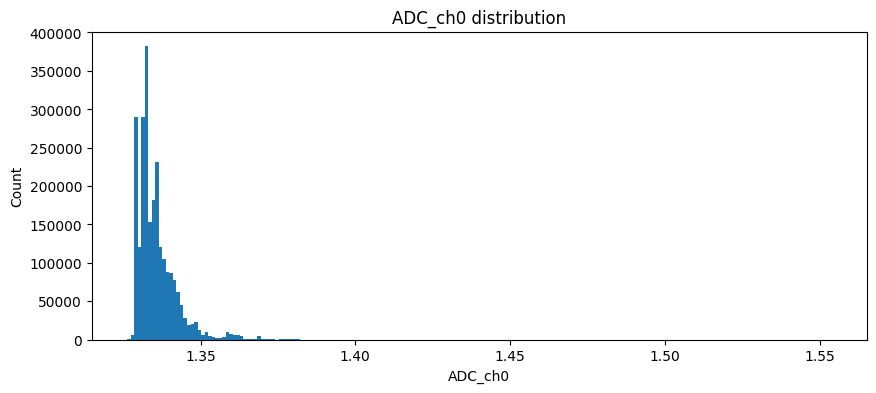

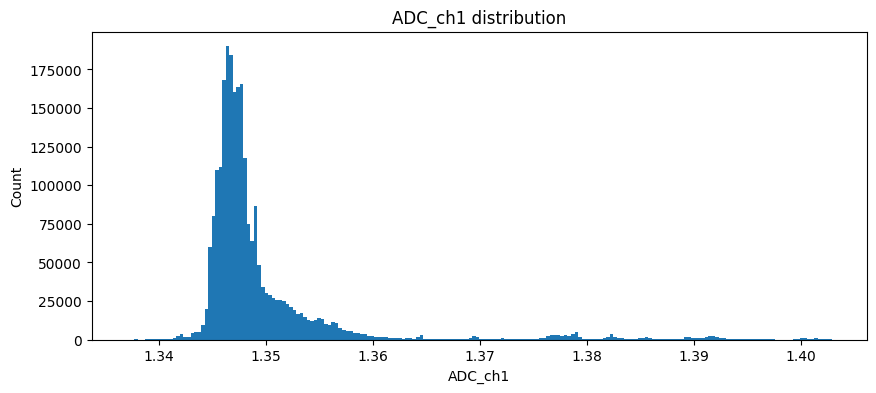

In [761]:
# inspecting ADC disttributions - help decide ylims & threshold
df[["ADC_ch0", "ADC_ch1"]].describe()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch0"].dropna(), bins=200)
plt.title("ADC_ch0 distribution")
plt.xlabel("ADC_ch0")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch1"].dropna(), bins=200)
plt.title("ADC_ch1 distribution")
plt.xlabel("ADC_ch1")
plt.ylabel("Count")
plt.show()

adc_disconnect_threshold = -1
gap_threshold_sec = 1

In [762]:
# pick cols to plot
plot_groups = {
    "IMU1 Euler": ["IMU1_H", "IMU1_P", "IMU1_R"],
    "IMU1 Quaternion": ["IMU1_W", "IMU1_X", "IMU1_Y", "IMU1_Z"],
    "IMU2 Euler": ["IMU2_H", "IMU2_P", "IMU2_R"],
    "IMU2 Quaternion": ["IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"],
    "ADC": ["ADC_ch0", "ADC_ch1"],
}

plot_groups = {
    k: [c for c in v if c in df.columns]
    for k, v in plot_groups.items()
    if any(c in df.columns for c in v)
}

plot_groups

{'IMU1 Euler': ['IMU1_H', 'IMU1_P', 'IMU1_R'],
 'IMU1 Quaternion': ['IMU1_W', 'IMU1_X', 'IMU1_Y', 'IMU1_Z'],
 'IMU2 Euler': ['IMU2_H', 'IMU2_P', 'IMU2_R'],
 'IMU2 Quaternion': ['IMU2_W', 'IMU2_X', 'IMU2_Y', 'IMU2_Z'],
 'ADC': ['ADC_ch0', 'ADC_ch1']}

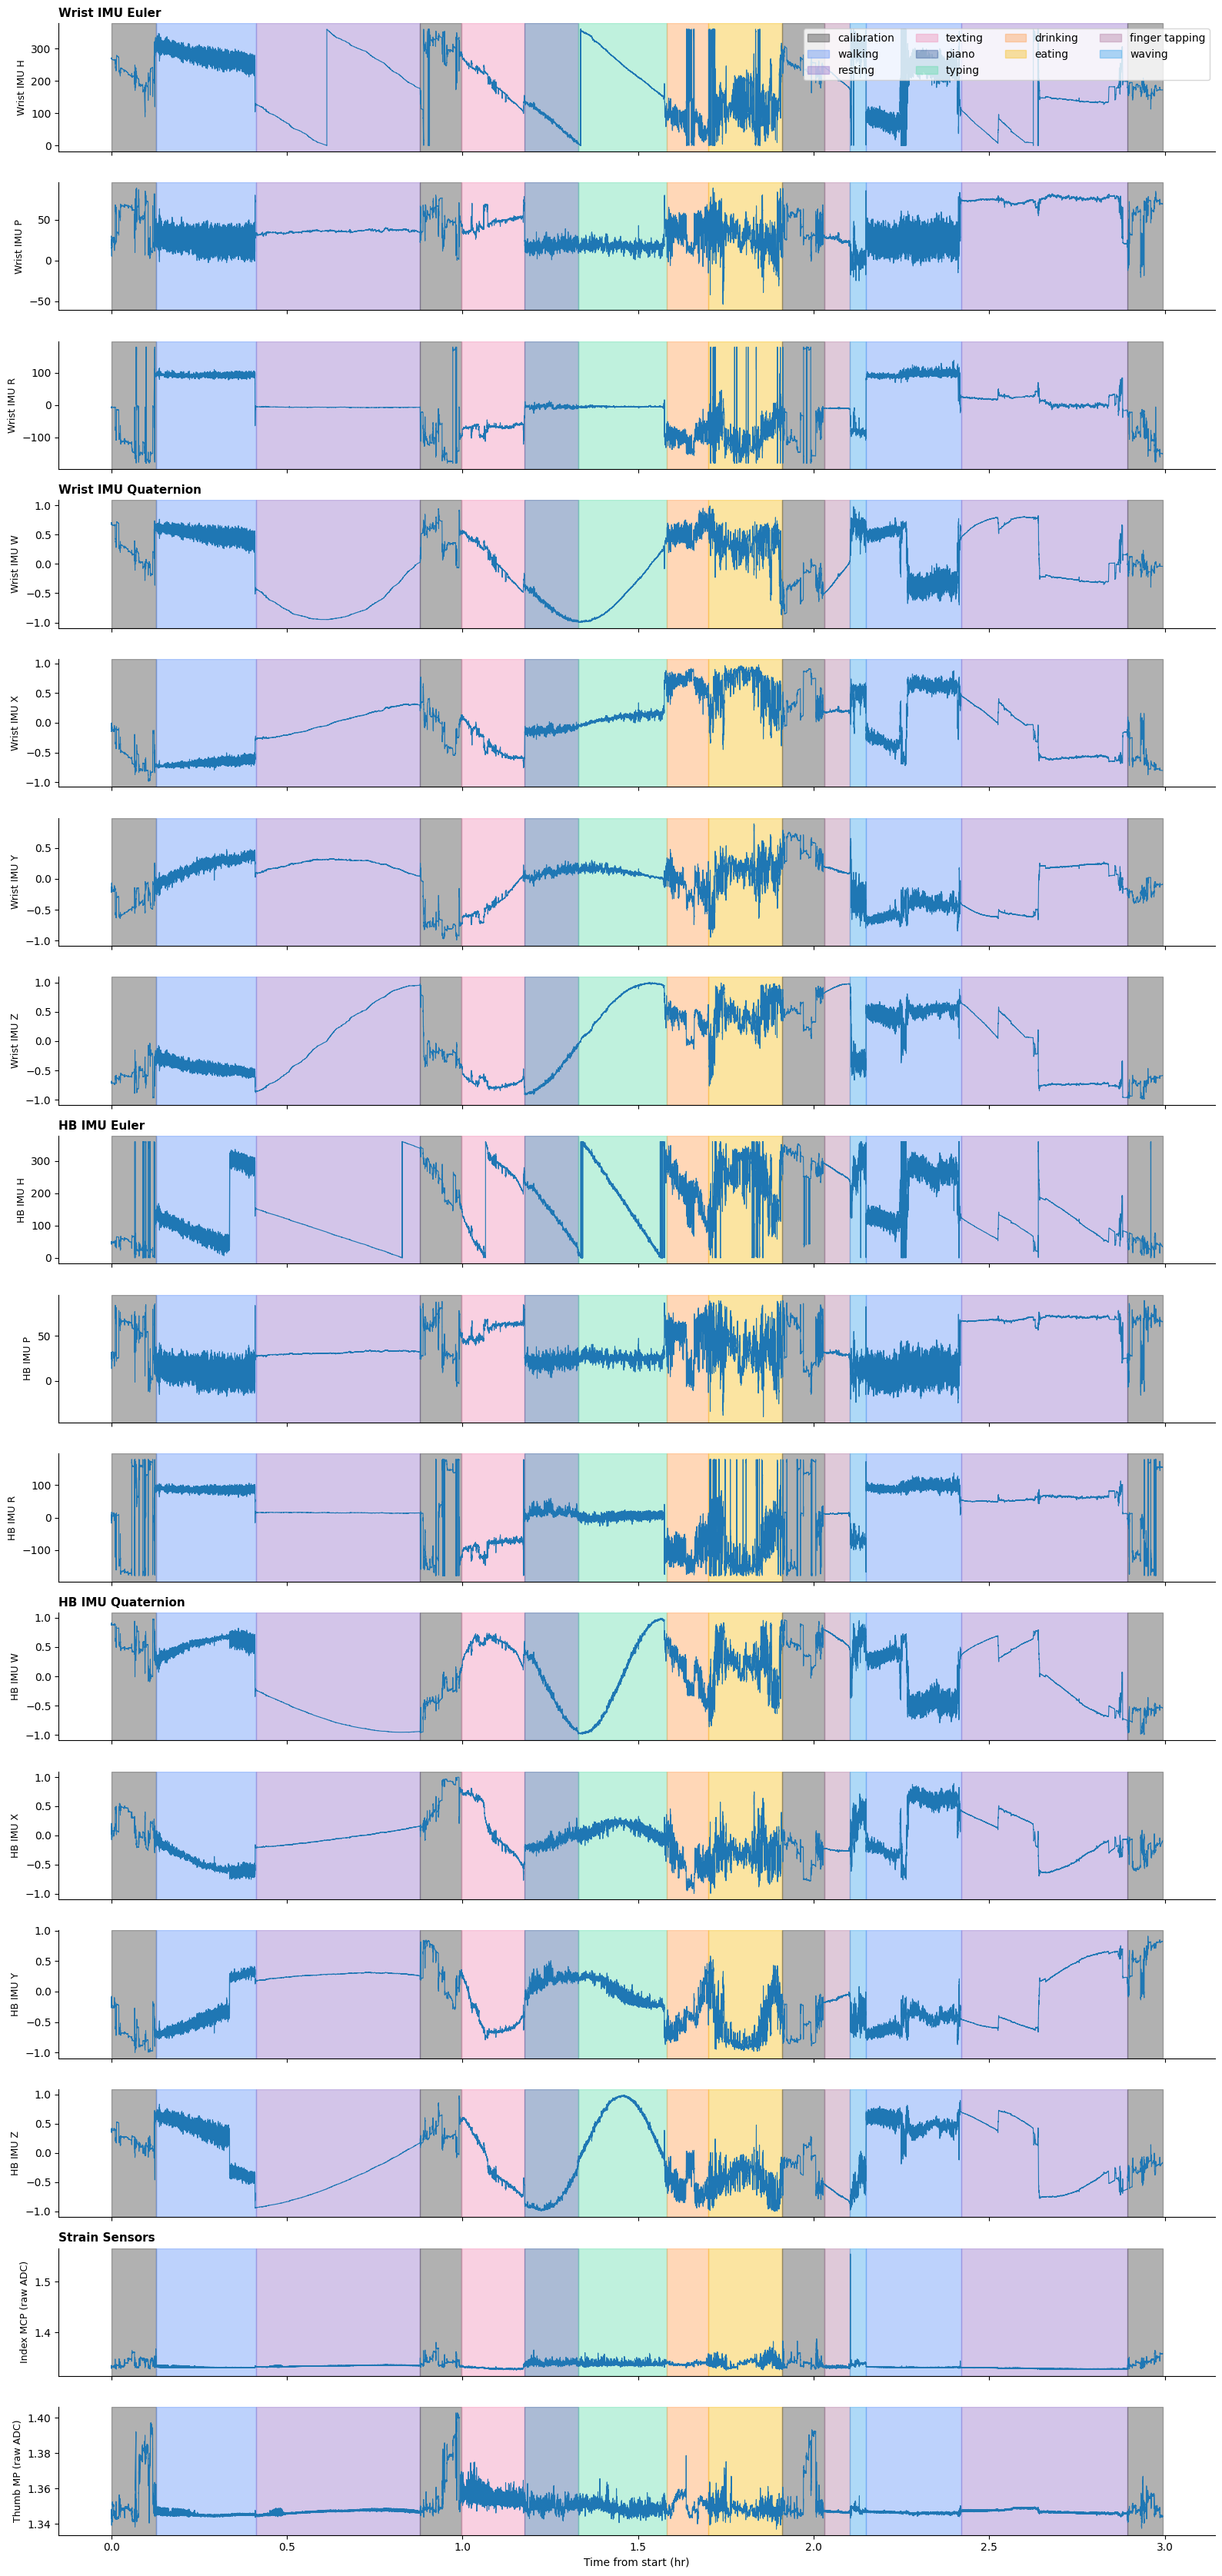

In [763]:
plot_all_signals_one_figure(
    df,
    plot_groups,
    manual_segments=manual_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    xcol="elapsed_hr",
)

In [764]:
# detecting ADC disconnect
adc0_disconnected_mask = df["ADC_ch0"] < adc_disconnect_threshold
adc1_disconnected_mask = df["ADC_ch1"] < adc_disconnect_threshold

print("Rows flagged as ADC_ch0 disconnected:", int(adc0_disconnected_mask.sum()))
print("Rows flagged as ADC_ch1 disconnected:", int(adc1_disconnected_mask.sum()))

adc0_disconnect_segments = mask_to_segments(df, adc0_disconnected_mask, "sensor disconnected")
for seg in adc0_disconnect_segments:
    seg["channel"] = "ADC_ch0"

adc1_disconnect_segments = mask_to_segments(df, adc1_disconnected_mask, "sensor disconnected")
for seg in adc1_disconnect_segments:
    seg["channel"] = "ADC_ch1"

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
pd.DataFrame(adc_disconnect_segments).head(20)

Rows flagged as ADC_ch0 disconnected: 0
Rows flagged as ADC_ch1 disconnected: 0


""


In [765]:
# detecting IMU2 disconnect 
imu2_zero_like = df.loc[
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6),
    ["Timestamp", "elapsed_min", "IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
]

print(f"Rows with IMU2 quaternion all ~0: {len(imu2_zero_like)}")
imu2_zero_like.head(20)


imu2_disconnected_mask = (
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6) &
    (df["IMU2_P"].abs() < 1e-6) &
    (df["IMU2_R"].abs() < 1e-6) &
    ((df["IMU2_H"] - 360).abs() < 1e-6)
)

print("Rows flagged as IMU2 disconnected:", int(imu2_disconnected_mask.sum()))
imu2_disconnect_segments = mask_to_segments(df, imu2_disconnected_mask, "IMU2 disconnected")

imu2_disconnect_segments_df = pd.DataFrame(imu2_disconnect_segments)
imu2_disconnect_segments_df.head(20)

Rows with IMU2 quaternion all ~0: 0
Rows flagged as IMU2 disconnected: 0


""


In [766]:
# detecting bluetooth-down
# dt_sec was around 0.002 -- so setting threshold to 0.5s for now
df["dt_sec"] = df["Timestamp"].diff().dt.total_seconds()
print(df["dt_sec"].describe())

gap_rows = df[df["dt_sec"] > gap_threshold_sec].copy()
print(f"Initially found {len(gap_rows)} possible Bluetooth gaps > {gap_threshold_sec} s")

bluetooth_segments = []

for idx in gap_rows.index:
    if idx == 0:
        continue

    prev_imu2_disc = bool(imu2_disconnected_mask.iloc[idx - 1]) if idx - 1 in imu2_disconnected_mask.index else False
    curr_imu2_disc = bool(imu2_disconnected_mask.iloc[idx]) if idx in imu2_disconnected_mask.index else False

    if prev_imu2_disc or curr_imu2_disc:
        continue

    bluetooth_segments.append({
        "start_min": float(df.loc[idx - 1, "elapsed_min"]),
        "end_min": float(df.loc[idx, "elapsed_min"]),
        "label": "bluetooth down",
        "gap_sec": float(df.loc[idx, "dt_sec"]),
        "start_time": df.loc[idx - 1, "Timestamp"],
        "end_time": df.loc[idx, "Timestamp"],
    })

bluetooth_segments_df = pd.DataFrame(bluetooth_segments)
print(f"Bluetooth gaps kept after excluding IMU2-disconnect boundaries: {len(bluetooth_segments)}")
bluetooth_segments_df

count    2.418088e+06
mean     4.456086e-03
std      3.914190e-03
min      0.000000e+00
25%      2.000000e-03
50%      3.000000e-03
75%      7.000000e-03
max      1.670000e-01
Name: dt_sec, dtype: float64
Initially found 0 possible Bluetooth gaps > 1 s
Bluetooth gaps kept after excluding IMU2-disconnect boundaries: 0


""


In [767]:
# clean up auto-detected segments
# note: all values below are in minutes

adc0_disconnect_segments = merge_close_segments(adc0_disconnect_segments, max_gap_min=0.002)   # 0.12 s
adc1_disconnect_segments = merge_close_segments(adc1_disconnect_segments, max_gap_min=0.002)   # 0.12 s
imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.002)   # 0.12 s
bluetooth_segments = merge_close_segments(bluetooth_segments, max_gap_min=0.01)                # 0.6 s

adc0_disconnect_segments = drop_tiny_segments(adc0_disconnect_segments, min_duration_min=0.0005)   # 0.03 s
adc1_disconnect_segments = drop_tiny_segments(adc1_disconnect_segments, min_duration_min=0.0005)   # 0.03 s
imu2_disconnect_segments = drop_tiny_segments(imu2_disconnect_segments, min_duration_min=0.002)    # 0.12 s # should be 0.002 UPDATE
bluetooth_segments = drop_tiny_segments(bluetooth_segments, min_duration_min=0.002)                # 0.12 s

imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.002)        # 0.12 s
imu2_disconnect_segments = keep_min_duration_segments(imu2_disconnect_segments, min_duration_min=0.002)  # 0.12 s

# combine both strain-sensor channels, then merge again so shading is cleaner
adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
adc_disconnect_segments = sorted(adc_disconnect_segments, key=lambda s: s["start_min"])
adc_disconnect_segments = merge_close_segments(adc_disconnect_segments, max_gap_min=0.002)         # 0.12 s

print("ADC_ch0 cleaned segments:", len(adc0_disconnect_segments))
print("ADC_ch1 cleaned segments:", len(adc1_disconnect_segments))
print("IMU2 cleaned segments:", len(imu2_disconnect_segments))
print("Bluetooth cleaned segments:", len(bluetooth_segments))
print("Combined ADC cleaned segments:", len(adc_disconnect_segments))

ADC_ch0 cleaned segments: 0
ADC_ch1 cleaned segments: 0
IMU2 cleaned segments: 0
Bluetooth cleaned segments: 0
Combined ADC cleaned segments: 0


In [768]:
# replace with NaNs
df_plot = df.copy()

if "ADC_ch0" in df_plot.columns:
    df_plot.loc[adc0_disconnected_mask, "ADC_ch0"] = np.nan

if "ADC_ch1" in df_plot.columns:
    df_plot.loc[adc1_disconnected_mask, "ADC_ch1"] = np.nan

if "wrist_flex_ext_deg" in df_plot.columns:
    df_plot.loc[imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
for col in imu2_cols:
    if col in df_plot.columns:
        df_plot.loc[imu2_disconnected_mask, col] = np.nan

In [769]:
# optional: chronological segment table after cleaning
all_segments_chron = []

for seg in manual_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "manual"
    })

for seg in bluetooth_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

for seg in adc_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": seg.get("channel", "auto")
    })

for seg in imu2_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

if all_segments_chron:
    all_segments_chron_df = (
        pd.DataFrame(all_segments_chron)
        .sort_values(["start_min", "end_min"])
        .reset_index(drop=True)
    )
else:
    all_segments_chron_df = pd.DataFrame(columns=["start_min", "end_min", "label", "source"])

display(all_segments_chron_df)

,start_min,end_min,label,source
0,0.000000,7.699932,calibration,manual
1,7.699933,24.772416,walking,manual
2,24.772417,52.755982,resting,manual
3,52.755983,59.774482,calibration,manual
4,59.774483,70.616249,texting,manual
5,70.616250,79.728632,piano,manual
6,79.728633,94.898716,typing,manual
7,94.898717,101.987599,drinking,manual
8,101.987600,114.567566,eating,manual
9,114.567567,121.876416,calibration,manual


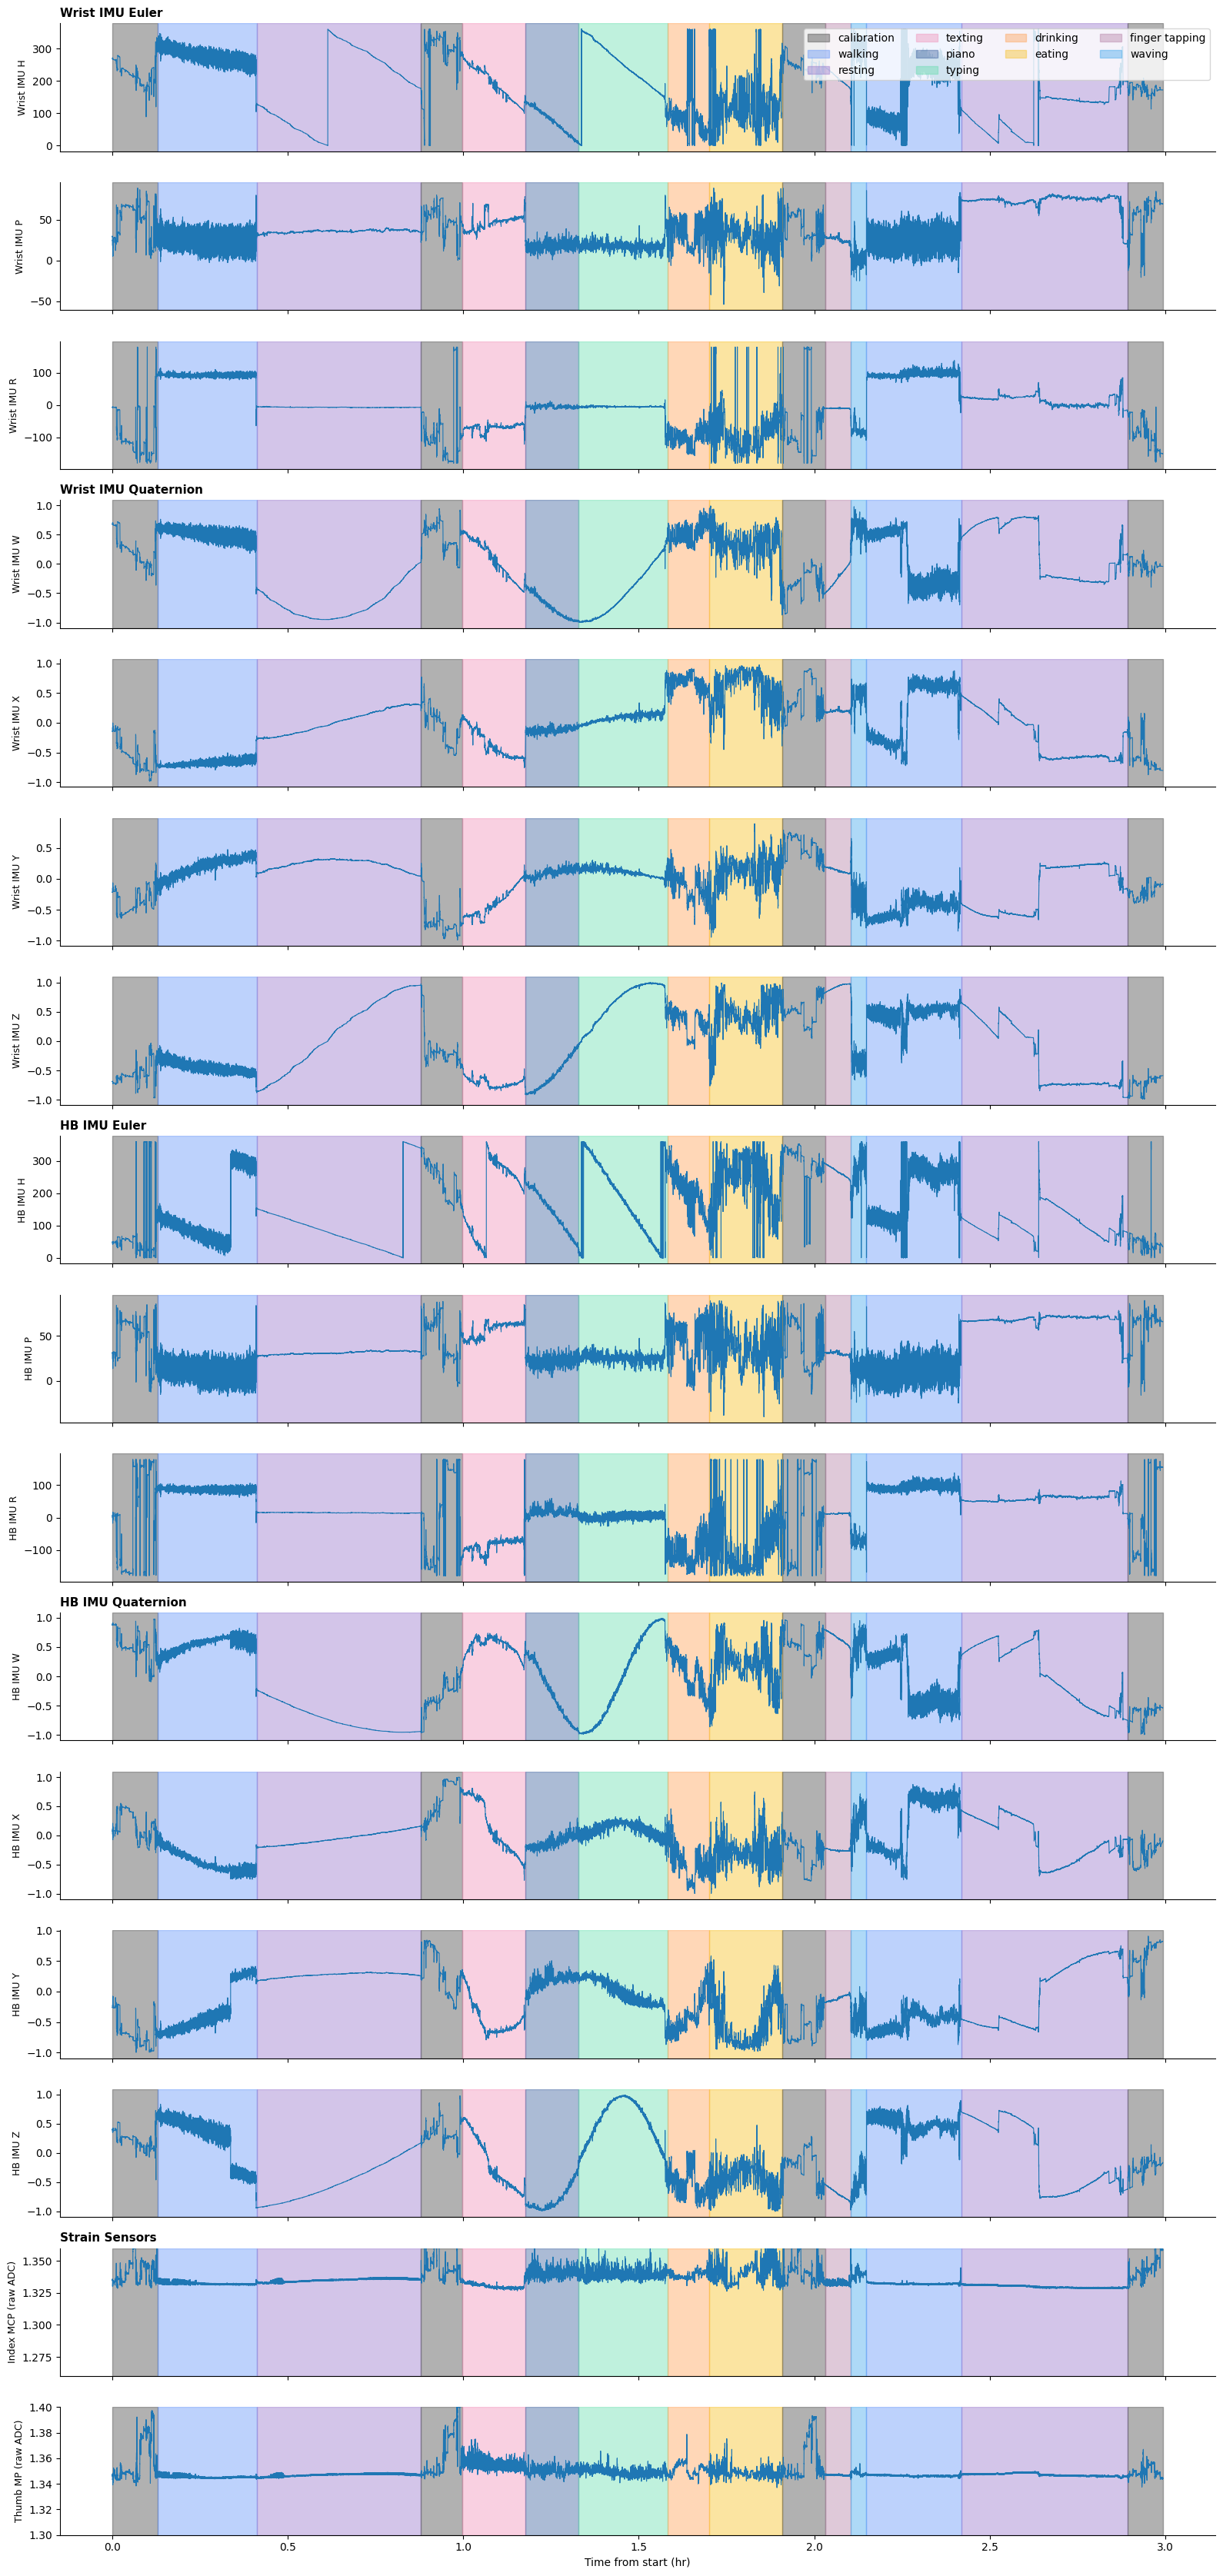

In [770]:
# optional: cleaned raw-signal plot (same channels as the first plot, but with disconnects blanked out)

plot_all_signals_one_figure(
    df_plot,
    plot_groups,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map,
    xcol="elapsed_hr",
)

# calibration (adc -> angle)

In [771]:
# participant-specific ADC -> angle calibration settings
# this calibration file is the source of the model we will reuse for this participant

CALIB_SESSION_DATE = "2026_04_02"
CALIB_FILE_PATTERNS = [
    "3hr_kinwatch_unified_*.csv",
    "battery_kinwatch_unified_*.csv", # 2 files for this wear 
]

CALIB_DURATION_SEC = 10.0
CALIB_POLY_ORDER = 2
CALIB_AGG = "mean"

CALIB_SENSOR_CHANNEL_MAP = {
    "index": "ADC_ch0",
    "thumb": "ADC_ch1",
}

CALIB_OUTPUT_COL_MAP = {
    "index": "index_mcp_deg",
    "thumb": "thumb_mp_deg",
}

CALIB_CLAMP_RANGE_MAP = {
    "index": (0.0, 90.0),
    "thumb": (0.0, 90.0),
}

In [772]:
# load and combine this participant's calibration files

calib_data_dir = data_root / CALIB_SESSION_DATE

calib_csv_paths = []
for pattern in CALIB_FILE_PATTERNS:
    matches = sorted(calib_data_dir.glob(pattern))
    if not matches:
        print(f"Warning: no files matching {pattern} found in {calib_data_dir}")
        continue
    calib_csv_paths.append(matches[-1])   # newest match for each pattern

if not calib_csv_paths:
    raise FileNotFoundError(
        f"No calibration files found in {calib_data_dir} for patterns: {CALIB_FILE_PATTERNS}"
    )

print("Using calibration files:")
for p in calib_csv_paths:
    print(" -", p.name)

calibration_parts = []

for path in calib_csv_paths:
    df_part = pd.read_csv(path)

    df_part["Timestamp"] = pd.to_datetime(
        df_part["Timestamp"], utc=True, errors="coerce"
    )
    df_part = (
        df_part
        .dropna(subset=["Timestamp"])
        .sort_values("Timestamp")
        .reset_index(drop=True)
    )

    # local time within this file
    part_t0 = df_part["Timestamp"].iloc[0]
    df_part["elapsed_sec_local"] = (
        df_part["Timestamp"] - part_t0
    ).dt.total_seconds()
    df_part["elapsed_min_local"] = df_part["elapsed_sec_local"] / 60.0

    df_part["calib_source"] = path.name
    calibration_parts.append(df_part)

# global combined calibration dataframe
calibration_df_raw = (
    pd.concat(calibration_parts, ignore_index=True)
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

cal_t0 = calibration_df_raw["Timestamp"].iloc[0]
calibration_df_raw["elapsed_sec"] = (
    calibration_df_raw["Timestamp"] - cal_t0
).dt.total_seconds()
calibration_df_raw["elapsed_min"] = calibration_df_raw["elapsed_sec"] / 60.0
calibration_df_raw["elapsed_hr"]  = calibration_df_raw["elapsed_sec"] / 3600.0

# where each source file starts on the combined/global elapsed_min axis
source_global_start_min = (
    calibration_df_raw
    .groupby("calib_source", sort=False)["elapsed_min"]
    .min()
    .to_dict()
)

print("\nGlobal start time (min) for each calibration source:")
display(pd.Series(source_global_start_min, name="global_start_min"))

all_note_rows = calibration_df_raw.loc[
    calibration_df_raw["Note"].fillna("").astype(str).str.strip() != ""
].copy()

print(f"Found {len(all_note_rows)} total non-empty note rows")
display(
    all_note_rows[
        [
            "calib_source",
            "Timestamp",
            "elapsed_min_local",
            "elapsed_min",
            "elapsed_hr",
            "Counter",
            "Note",
        ]
    ]
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(
        all_note_rows[
            [
                "calib_source",
                "Timestamp",
                "elapsed_min_local",
                "elapsed_min",
                "elapsed_hr",
                "Counter",
                "Note",
            ]
        ]
    )

Using calibration files:
 - 3hr_kinwatch_unified_20260402_103541.csv
 - battery_kinwatch_unified_20260402_133548.csv


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/3784172702.py:25: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_part = pd.read_csv(path)
/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/3784172702.py:25: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_part = pd.read_csv(path)



Global start time (min) for each calibration source:


3hr_kinwatch_unified_20260402_103541.csv          0.000000
battery_kinwatch_unified_20260402_133548.csv    180.113083
Name: global_start_min, dtype: float64

Found 91 total non-empty note rows


,calib_source,Timestamp,elapsed_min_local,elapsed_min,elapsed_hr,Counter,Note
8470,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:36:19+00:00,0.622517,0.622517,0.010375,10587.0,calib
13202,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:36:39.604000+00:00,0.965917,0.965917,0.016099,12638.0,index 0
24044,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:37:27.244000+00:00,1.759917,1.759917,0.029332,17375.0,index 22.5
33952,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:38:10.920000+00:00,2.487850,2.487850,0.041464,21727.0,index 45
42663,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:38:49.244000+00:00,3.126583,3.126583,0.052110,25544.0,index 67.5
...,...,...,...,...,...,...,...
5896279,battery_kinwatch_unified_20260402_133548.csv,2026-04-03 00:50:30.892000+00:00,254.707633,434.820717,7.247012,2599482.0,thumb 67.5
5905245,battery_kinwatch_unified_20260402_133548.csv,2026-04-03 00:51:10.779000+00:00,255.372417,435.485500,7.258092,2603442.0,thumb 90
5908738,battery_kinwatch_unified_20260402_133548.csv,2026-04-03 00:51:26.845000+00:00,255.640183,435.753267,7.262554,2605049.0,calib done
6071072,battery_kinwatch_unified_20260402_133548.csv,2026-04-03 01:03:19.289000+00:00,267.514250,447.627333,7.460456,2675809.0,walking since after calib


,calib_source,Timestamp,elapsed_min_local,elapsed_min,elapsed_hr,Counter,Note
8470,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:36:19+00:00,0.622517,0.622517,0.010375,10587.0,calib
13202,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:36:39.604000+00:00,0.965917,0.965917,0.016099,12638.0,index 0
24044,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:37:27.244000+00:00,1.759917,1.759917,0.029332,17375.0,index 22.5
33952,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:38:10.920000+00:00,2.487850,2.487850,0.041464,21727.0,index 45
42663,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:38:49.244000+00:00,3.126583,3.126583,0.052110,25544.0,index 67.5
50475,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:39:23.578000+00:00,3.698817,3.698817,0.061647,28961.0,index 90
60922,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:40:09.320000+00:00,4.461183,4.461183,0.074353,33513.0,thumb 0
69416,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:40:46.461000+00:00,5.080200,5.080200,0.084670,37212.0,thhumb 22.5
74679,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:41:09.619000+00:00,5.466167,5.466167,0.091103,39518.0,thumb 45
82874,3hr_kinwatch_unified_20260402_103541.csv,2026-04-02 17:41:45.510000+00:00,6.064350,6.064350,0.101072,43090.0,thumb 67.5


In [773]:
CALIB_HOLD_SEC = 10.0

CALIB_SOURCE_3HR = [p.name for p in calib_csv_paths if p.name.startswith("3hr_kinwatch_unified_")][0]
CALIB_SOURCE_BATTERY = [p.name for p in calib_csv_paths if p.name.startswith("battery_kinwatch_unified_")][0]

manual_calibration_segments = pd.DataFrame([
    # initial calib (3hr file local times)
    {"set_label": "start", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 0.965917},
    {"set_label": "start", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 1.759917},
    {"set_label": "start", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 2.487850},
    {"set_label": "start", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 3.126583},
    {"set_label": "start", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 3.698817},

    {"set_label": "start", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 4.461183},
    {"set_label": "start", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 5.080200},
    {"set_label": "start", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 5.466167},
    {"set_label": "start", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 6.064350},
    {"set_label": "start", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 6.823983},

    # +1hr (3hr file local times)
    {"set_label": "+1hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 53.040317},
    {"set_label": "+1hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 54.171667},
    {"set_label": "+1hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 54.596233},
    {"set_label": "+1hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 55.086567},
    {"set_label": "+1hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 55.637333},

    {"set_label": "+1hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 56.068917},
    {"set_label": "+1hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 57.102100},
    {"set_label": "+1hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 57.923450},
    {"set_label": "+1hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 58.487650},
    {"set_label": "+1hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 59.166817},

    # +2hr (3hr file local times)
    {"set_label": "+2hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 115.131167},
    {"set_label": "+2hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 115.730133},
    {"set_label": "+2hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 116.334983},
    {"set_label": "+2hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 116.868933},
    {"set_label": "+2hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 117.488117},

    {"set_label": "+2hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_3HR, "start_min_local": 117.920550},
    {"set_label": "+2hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 118.440150},
    {"set_label": "+2hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 118.872400},
    {"set_label": "+2hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 119.276617},
    {"set_label": "+2hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_3HR, "start_min_local": 120.079083},

    # # +4hr calib -- (battery_ axis)
    # {"set_label": "+3hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 0.0,  "start_min": 250.598983},
    # {"set_label": "+3hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 22.5, "start_min": 251.172383},
    # {"set_label": "+3hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 45.0, "start_min": 251.791017},
    # {"set_label": "+3hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 67.5, "start_min": 252.246017},
    # {"set_label": "+3hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 90, "start_min": 252.791333},

    # {"set_label": "+3hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 0.0,  "start_min": 253.225983},
    # {"set_label": "+3hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 22.5, "start_min": 253.799933},
    # {"set_label": "+3hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 45.0, "start_min": 254.299467},
    # {"set_label": "+3hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 67.5, "start_min": 254.707633},
    # {"set_label": "+3hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 90, "start_min": 255.372417},

    # +4hr calib (battery file LOCAL elapsed_min values)
    {"set_label": "+4hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 250.598983},
    {"set_label": "+4hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 251.172383},
    {"set_label": "+4hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 251.791017},
    {"set_label": "+4hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 252.246017},
    {"set_label": "+4hr", "sensor": "index", "channel": "ADC_ch0", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 252.791333},

    {"set_label": "+4hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 0.0,  "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 253.225983},
    {"set_label": "+4hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 22.5, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 253.799933},
    {"set_label": "+4hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 45.0, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 254.299467},
    {"set_label": "+4hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 67.5, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 254.707633},
    {"set_label": "+4hr", "sensor": "thumb", "channel": "ADC_ch1", "angle_deg": 90.0, "calib_source": CALIB_SOURCE_BATTERY, "start_min_local": 255.372417},
])

manual_calibration_segments["start_min"] = (
    manual_calibration_segments["start_min_local"]
    + manual_calibration_segments["calib_source"].map(source_global_start_min)
)

manual_calibration_segments["end_min"] = (
    manual_calibration_segments["start_min"] + CALIB_HOLD_SEC / 60.0
)

manual_calibration_segments["label"] = (
    manual_calibration_segments["set_label"] + " | " +
    manual_calibration_segments["sensor"] + " | " +
    manual_calibration_segments["angle_deg"].astype(str) + " deg"
)

display(
    manual_calibration_segments[
        manual_calibration_segments["set_label"] == "+4hr"
    ][["sensor", "angle_deg", "start_min_local", "start_min"]]
)

,sensor,angle_deg,start_min_local,start_min
30,index,0.0,250.598983,430.712066
31,index,22.5,251.172383,431.285466
32,index,45.0,251.791017,431.904100
33,index,67.5,252.246017,432.359100
34,index,90.0,252.791333,432.904416
35,thumb,0.0,253.225983,433.339066
36,thumb,22.5,253.799933,433.913016
37,thumb,45.0,254.299467,434.412550
38,thumb,67.5,254.707633,434.820716
39,thumb,90.0,255.372417,435.485500


In [774]:
# build calib table
all_calibration_data_df = build_adc_calibration_table_from_spec(
    calibration_df_raw,
    manual_calibration_segments,
    time_col="elapsed_min",
    agg=CALIB_AGG,
)

print("All calibration points:")
display(all_calibration_data_df)

All calibration points:


,set_label,sensor,channel,angle_deg,start_min,end_min,adc_mean,adc_std,n,label
0,+1hr,index,ADC_ch0,0.0,53.040317,53.206984,1.338096,0.000233,2309,+1hr | index | 0.0 deg
1,+1hr,index,ADC_ch0,22.5,54.171667,54.338334,1.342737,0.000163,2200,+1hr | index | 22.5 deg
2,+1hr,index,ADC_ch0,45.0,54.596233,54.762900,1.348505,0.000262,2354,+1hr | index | 45.0 deg
3,+1hr,index,ADC_ch0,67.5,55.086567,55.253234,1.362801,0.000256,2315,+1hr | index | 67.5 deg
4,+1hr,index,ADC_ch0,90.0,55.637333,55.804000,1.368825,0.000245,2249,+1hr | index | 90.0 deg
5,+1hr,thumb,ADC_ch1,0.0,56.068917,56.235584,1.348953,0.000203,2285,+1hr | thumb | 0.0 deg
6,+1hr,thumb,ADC_ch1,22.5,57.102100,57.268767,1.364440,0.000152,2292,+1hr | thumb | 22.5 deg
7,+1hr,thumb,ADC_ch1,45.0,57.923450,58.090117,1.378942,0.000235,2312,+1hr | thumb | 45.0 deg
8,+1hr,thumb,ADC_ch1,67.5,58.487650,58.654317,1.389341,0.000216,2327,+1hr | thumb | 67.5 deg
9,+1hr,thumb,ADC_ch1,90.0,59.166817,59.333484,1.401150,0.000507,2300,+1hr | thumb | 90.0 deg


,sensor,channel,fit_order,n_points,normalize_adc,adc_min,adc_max,angle_min,angle_max,coeffs
0,index | +1hr,ADC_ch0,2,5,True,1.338096,1.368825,0.0,90.0,"[-41.611874, 123.873295, 3.019885]"
1,index | +2hr,ADC_ch0,2,5,True,1.332397,1.359972,0.0,90.0,"[-53.336558, 147.855885, -3.233972]"
2,index | +4hr,ADC_ch0,2,5,True,1.334719,1.362475,0.0,90.0,"[-66.625727, 156.050775, 0.848679]"
3,index | start,ADC_ch0,2,5,True,1.333747,1.361641,0.0,90.0,"[-58.628571, 139.808997, 9.412977]"
4,thumb | +1hr,ADC_ch1,2,5,True,1.348953,1.401150,0.0,90.0,"[2.279183e+01, 6.765002e+01, 1.991464e-02]"
5,thumb | +2hr,ADC_ch1,2,5,True,1.345653,1.391750,0.0,90.0,"[88.716483, 1.777585, -0.208452]"
6,thumb | +4hr,ADC_ch1,2,5,True,1.351572,1.396564,0.0,90.0,"[24.114922, 63.25749 , -0.248125]"
7,thumb | start,ADC_ch1,2,5,True,1.344143,1.393519,0.0,90.0,"[131.870417, -37.71404 , -0.514591]"


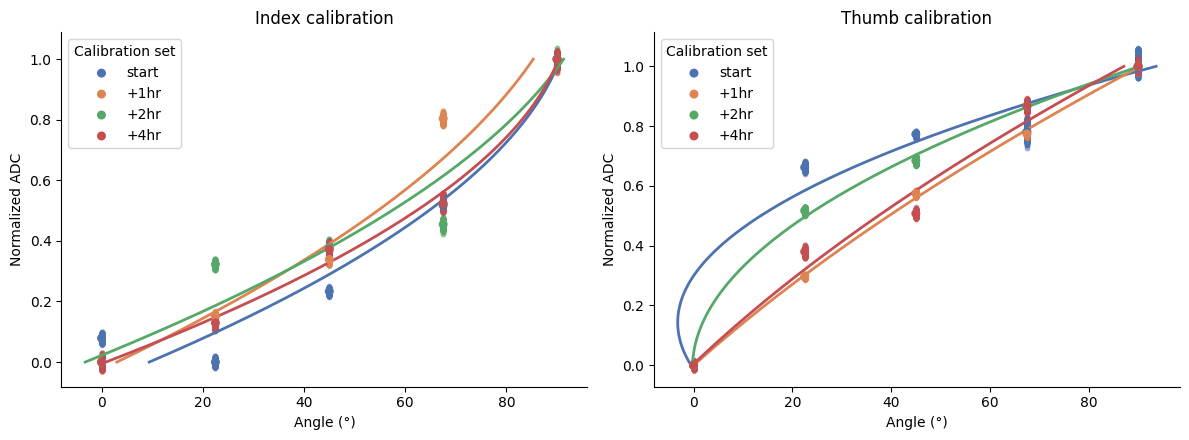

In [775]:
fit_df = all_calibration_data_df.copy()
fit_df["curve_key"] = fit_df["sensor"] + " | " + fit_df["set_label"]

calibration_models_by_set = fit_adc_angle_models(
    fit_df,
    poly_order=CALIB_POLY_ORDER,
    group_col="curve_key",
    normalize_adc=True,
)

display(summarize_adc_angle_models(calibration_models_by_set))

SET_ORDER = ["start", "+1hr", "+2hr", "+4hr"]

SET_COLOR_MAP = {
    "start": "#4C72B0",
    "+1hr":  "#DD8452",
    "+2hr":  "#55A868",
    "+4hr":  "#C44E52",
}

plot_calibration_sets_by_sensor(
    calibration_df_raw,
    manual_calibration_segments,
    all_calibration_data_df,
    calibration_models_by_set,
    time_col="elapsed_min",
    figsize=(12, 4.5),
    normal=True, 
    set_order=SET_ORDER,
    set_color_map=SET_COLOR_MAP,
)

In [776]:
# cross-calibration MAE/ RMSE in degs
from ast import literal_eval
import numpy as np
import pandas as pd

model_df = summarize_adc_angle_models(calibration_models_by_set).copy()
model_df = model_df.rename(columns={"sensor": "curve_key"})
model_df[["sensor", "set_label"]] = model_df["curve_key"].str.split(r" \| ", n=1, expand=True)

set_order = ["start", "+1hr", "+2hr", "+4hr"]
model_df["set_label"] = pd.Categorical(model_df["set_label"], categories=set_order, ordered=True)

fit_points_df = all_calibration_data_df.copy()
fit_points_df["set_label"] = pd.Categorical(fit_points_df["set_label"], categories=set_order, ordered=True)

def parse_coeffs(coeffs):
    if isinstance(coeffs, str):
        coeffs = literal_eval(coeffs)
    return np.asarray(coeffs, dtype=float).ravel()

def predict_angle_from_model_row(model_row, adc_values):
    x = np.asarray(adc_values, dtype=float)

    if bool(model_row["normalize_adc"]):
        adc_min = float(model_row["adc_min"])
        adc_max = float(model_row["adc_max"])
        denom = adc_max - adc_min
        if denom == 0:
            raise ValueError(f"adc_max == adc_min for {model_row['curve_key']}")
        x = (x - adc_min) / denom

    coeffs = parse_coeffs(model_row["coeffs"])
    return np.polyval(coeffs, x)

def compute_cross_calibration_errors(points_df, model_df):
    records = []

    for sensor in sorted(points_df["sensor"].unique()):
        sensor_points = points_df[points_df["sensor"] == sensor].copy()
        sensor_models = model_df[model_df["sensor"] == sensor].copy()

        for _, mrow in sensor_models.iterrows():
            model_set = mrow["set_label"]

            for data_set, sub in sensor_points.groupby("set_label", observed=False):
                if sub.empty:
                    continue

                sub = sub.sort_values("angle_deg").copy()
                y_true = sub["angle_deg"].to_numpy(dtype=float)
                adc = sub["adc_mean"].to_numpy(dtype=float)
                y_pred = predict_angle_from_model_row(mrow, adc)

                err = y_pred - y_true
                abs_err = np.abs(err)

                records.append({
                    "sensor": sensor,
                    "model_set": model_set,
                    "data_set": data_set,
                    "mae_deg": abs_err.mean(),
                    "rmse_deg": np.sqrt(np.mean(err**2)),
                    "max_abs_err_deg": abs_err.max(),
                    "signed_bias_deg": err.mean(),
                })

    out = pd.DataFrame(records)
    out["model_set"] = pd.Categorical(out["model_set"], categories=set_order, ordered=True)
    out["data_set"] = pd.Categorical(out["data_set"], categories=set_order, ordered=True)
    return out.sort_values(["sensor", "model_set", "data_set"]).reset_index(drop=True)

cross_err_df = compute_cross_calibration_errors(fit_points_df, model_df)
display(cross_err_df.round(2))

,sensor,model_set,data_set,mae_deg,rmse_deg,max_abs_err_deg,signed_bias_deg
0,index,start,start,8.26,11.08,20.06,0.00
1,index,start,+1hr,20.82,22.89,29.78,20.82
2,index,start,+2hr,7.82,10.68,20.46,2.85
3,index,start,+4hr,7.31,8.97,14.21,7.31
4,index,+1hr,start,24.39,27.05,37.84,-24.39
5,index,+1hr,+1hr,4.49,5.00,8.21,0.00
6,index,+1hr,+2hr,22.23,24.46,38.98,-22.23
7,index,+1hr,+4hr,17.14,17.75,24.95,-17.14
8,index,+2hr,start,10.22,11.86,18.62,-2.82
9,index,+2hr,+1hr,20.73,21.69,27.45,20.73


In [777]:
for sensor in ["index", "thumb"]:
    print(f"\n{sensor.upper()} — cross-calibration MAE (deg)")
    display(
        cross_err_df[cross_err_df["sensor"] == sensor]
        .pivot(index="model_set", columns="data_set", values="mae_deg")
        .round(2)
    )

    print(f"\n{sensor.upper()} — cross-calibration RMSE (deg)")
    display(
        cross_err_df[cross_err_df["sensor"] == sensor]
        .pivot(index="model_set", columns="data_set", values="rmse_deg")
        .round(2)
    )


INDEX — cross-calibration MAE (deg)


data_set,start,+1hr,+2hr,+4hr
model_set,,,,
start,8.26,20.82,7.82,7.31
+1hr,24.39,4.49,22.23,17.14
+2hr,10.22,20.73,7.11,5.10
+4hr,11.51,15.73,9.82,2.30



INDEX — cross-calibration RMSE (deg)


data_set,start,+1hr,+2hr,+4hr
model_set,,,,
start,11.08,22.89,10.68,8.97
+1hr,27.05,5.00,24.46,17.75
+2hr,11.86,21.69,9.93,6.01
+4hr,14.74,17.29,11.41,2.79



THUMB — cross-calibration MAE (deg)


data_set,start,+1hr,+2hr,+4hr
model_set,,,,
start,7.02,15.09,6.37,12.57
+1hr,12.71,0.76,8.29,5.34
+2hr,9.56,12.83,1.06,9.94
+4hr,12.47,3.96,7.28,4.02



THUMB — cross-calibration RMSE (deg)


data_set,start,+1hr,+2hr,+4hr
model_set,,,,
start,9.13,20.59,7.21,13.87
+1hr,13.74,0.96,10.23,6.05
+2hr,11.39,19.42,1.41,12.89
+4hr,13.12,4.66,8.43,4.62


In [778]:
pivot = all_calibration_data_df.pivot_table(
    index=["sensor", "angle_deg"],
    columns="set_label",
    values="adc_mean"
)
display(pivot)

set_label             +1hr      +2hr      +4hr     start
sensor angle_deg                                        
index  0.0        1.338096  1.332397  1.334719  1.335944
       22.5       1.342737  1.341297  1.338308  1.333747
       45.0       1.348505  1.342826  1.345029  1.340261
       67.5       1.362801  1.344933  1.349267  1.348185
       90.0       1.368825  1.359972  1.362475  1.361641
thumb  0.0        1.348953  1.345653  1.351572  1.344143
       22.5       1.364440  1.369476  1.368667  1.376826
       45.0       1.378942  1.377196  1.374412  1.382306
       67.5       1.389341  1.385605  1.390603  1.382703
       90.0       1.401150  1.391750  1.396564  1.393519

,set_label,sensor,channel,angle_deg,start_min,end_min,adc_mean,adc_std,n,label
30,start,index,ADC_ch0,0.0,0.965917,1.132584,1.335944,0.000213,2239,start | index | 0.0 deg
31,start,index,ADC_ch0,22.5,1.759917,1.926584,1.333747,0.000178,2259,start | index | 22.5 deg
32,start,index,ADC_ch0,45.0,2.487850,2.654517,1.340261,0.000147,2253,start | index | 45.0 deg
33,start,index,ADC_ch0,67.5,3.126583,3.293250,1.348185,0.000183,2308,start | index | 67.5 deg
34,start,index,ADC_ch0,90.0,3.698817,3.865484,1.361641,0.000211,2266,start | index | 90.0 deg
35,start,thumb,ADC_ch1,0.0,4.461183,4.627850,1.344143,0.000225,2281,start | thumb | 0.0 deg
36,start,thumb,ADC_ch1,22.5,5.080200,5.246867,1.376826,0.000459,2254,start | thumb | 22.5 deg
37,start,thumb,ADC_ch1,45.0,5.466167,5.632834,1.382306,0.000187,2294,start | thumb | 45.0 deg
38,start,thumb,ADC_ch1,67.5,6.064350,6.231017,1.382703,0.000880,2274,start | thumb | 67.5 deg
39,start,thumb,ADC_ch1,90.0,6.823983,6.990650,1.393519,0.001017,2289,start | thumb | 90.0 deg


,sensor,channel,fit_order,n_points,normalize_adc,adc_min,adc_max,angle_min,angle_max,coeffs
0,index,ADC_ch0,2,5,True,1.333747,1.361641,0.0,90.0,"[-58.628571, 139.808997, 9.412977]"
1,thumb,ADC_ch1,2,5,True,1.344143,1.393519,0.0,90.0,"[131.870417, -37.71404 , -0.514591]"


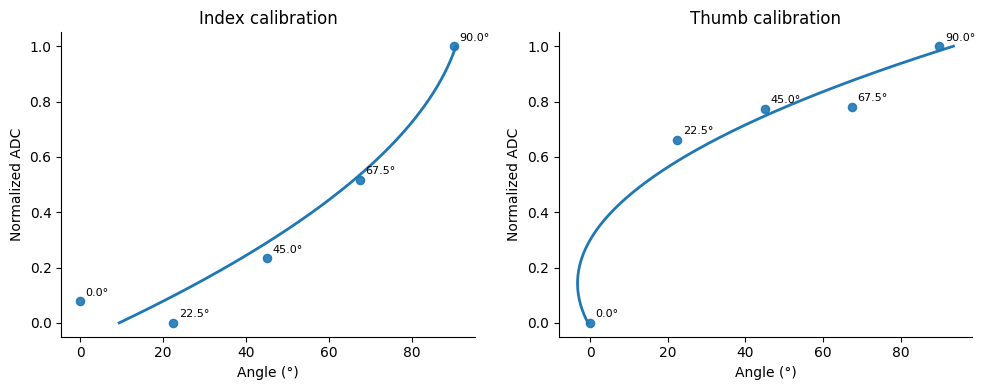

In [779]:
# pick which calib curve to use
fit_set_labels = ["start"]   # change start, +1hr, +2hr, +4hr

# new calibration-model options
CALIB_NORMALIZE_ADC = True      # fit in normalized-ADC space using fit_set_labels min/max
CALIB_CLIP_NORMALIZED = False    # when applying to wear data, clip normalized ADC to [0, 1]

calibration_table_for_fit = all_calibration_data_df[
    all_calibration_data_df["set_label"].isin(fit_set_labels)
].copy()

display(calibration_table_for_fit)


# fit participant-specific ADC -> angle models

participant_calib_models = fit_adc_angle_models(
    calibration_table_for_fit,
    poly_order=CALIB_POLY_ORDER,
    group_col="sensor",
    normalize_adc=CALIB_NORMALIZE_ADC,
)

display(summarize_adc_angle_models(participant_calib_models))

plot_adc_calibration_models(
    calibration_table_for_fit,
    participant_calib_models,
    figsize=(10, 4),
    normal=CALIB_NORMALIZE_ADC,
)

In [780]:
# calibration fit check: true angle, avg ADC, predicted angle, residual

calibration_fit_rows = []

for sensor, model in participant_calib_models.items():
    sub = calibration_table_for_fit[calibration_table_for_fit["sensor"] == sensor].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("angle_deg").reset_index(drop=True)
    sub["pred_angle_deg"] = model["poly"](sub["adc_mean"].to_numpy(dtype=float))
    sub["residual_deg"] = sub["pred_angle_deg"] - sub["angle_deg"]

    calibration_fit_rows.append(sub)

calibration_fit_check = pd.concat(calibration_fit_rows, ignore_index=True)

display(
    calibration_fit_check[
        [
            "sensor",
            "channel",
            "angle_deg",
            "adc_mean",
            "adc_std",
            "n",
            "pred_angle_deg",
            "residual_deg",
        ]
    ]
)

,sensor,channel,angle_deg,adc_mean,adc_std,n,pred_angle_deg,residual_deg
0,index,ADC_ch0,0.0,1.335944,0.000213,2239,91.552835,91.552835
1,index,ADC_ch0,22.5,1.333747,0.000178,2259,91.589547,69.089547
2,index,ADC_ch0,45.0,1.340261,0.000147,2253,91.479049,46.479049
3,index,ADC_ch0,67.5,1.348185,0.000183,2308,91.337924,23.837924
4,index,ADC_ch0,90.0,1.361641,0.000211,2266,91.081390,1.081390
5,thumb,ADC_ch1,0.0,1.344143,0.000225,2281,187.045425,187.045425
6,thumb,ADC_ch1,22.5,1.376826,0.000459,2254,197.540030,175.040030
7,thumb,ADC_ch1,45.0,1.382306,0.000187,2294,199.327015,154.327015
8,thumb,ADC_ch1,67.5,1.382703,0.000880,2274,199.456880,131.956880
9,thumb,ADC_ch1,90.0,1.393519,0.001017,2289,203.008574,113.008574


In [781]:
# apply wrist FE + participant-specific ADC calibration to cleaned data

FE_SOURCE_COL       = "imu_azimuth_deg"   # or "imu_bend_deg" / "imu_pitch_deg"
SIGN                = 1.0                 # flip to -1.0 if polarity is reversed
ZERO_BASELINE       = True
BASELINE_WINDOW_SEC = 1.0
BASELINE_STAT       = "median"

df_final = df_plot.copy()

df_final = add_wrist_flex_ext_from_imus(
    df_final,
    fe_source_col=FE_SOURCE_COL,
    out_col="wrist_flex_ext_deg",
    sign=SIGN,
    zero_baseline=ZERO_BASELINE,
    baseline_window_sec=BASELINE_WINDOW_SEC,
    baseline_stat=BASELINE_STAT,
)

if "wrist_flex_ext_deg" in df_final.columns:
    df_final.loc[imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

df_final = apply_adc_angle_models(
    df_final,
    participant_calib_models,
    output_col_map=CALIB_OUTPUT_COL_MAP,
    clamp=False, # ignoreing this for now 
    clamp_range_map=CALIB_CLAMP_RANGE_MAP,
)


fit_set_str = ", ".join(fit_set_labels)
display_name_map["wrist_flex_ext_deg"] = (
    f"Wrist Flex/Ext (°)\n[{FE_SOURCE_COL}, sign={SIGN:+.0f}]"
)
display_name_map["index_mcp_deg"] = (
    f"Index MCP Angle (°)\n[{fit_set_str} fit-set normalized ADC calibration]"
)
display_name_map["thumb_mp_deg"] = (
    f"Thumb MP Angle (°)\n[{fit_set_str} fit-set normalized ADC calibration]"
)

group_title_map["Wrist FE"] = "Wrist flexion / extension"
group_title_map["Finger angles"] = "Finger bend angles from participant-specific ADC calibration"

print("Final columns now available:")
display(
    df_final[
        [c for c in ["wrist_flex_ext_deg", "index_mcp_deg", "thumb_mp_deg"] if c in df_final.columns]
    ].describe()
)


Final columns now available:


,wrist_flex_ext_deg,index_mcp_deg,thumb_mp_deg
count,2.418089e+06,2.418087e+06,2.418089e+06
mean,-1.315626e+01,2.217095e+01,-8.468598e-02
std,3.000450e+01,1.885863e+01,1.145744e+01
min,-1.076932e+02,9.412977e+00,-3.211081e+00
25%,-2.708002e+01,9.412977e+00,-2.716065e+00
50%,-1.309774e+01,1.061348e+01,-2.238974e+00
75%,2.978788e+00,2.959597e+01,-1.707360e+00
max,7.035440e+01,9.059340e+01,9.364179e+01


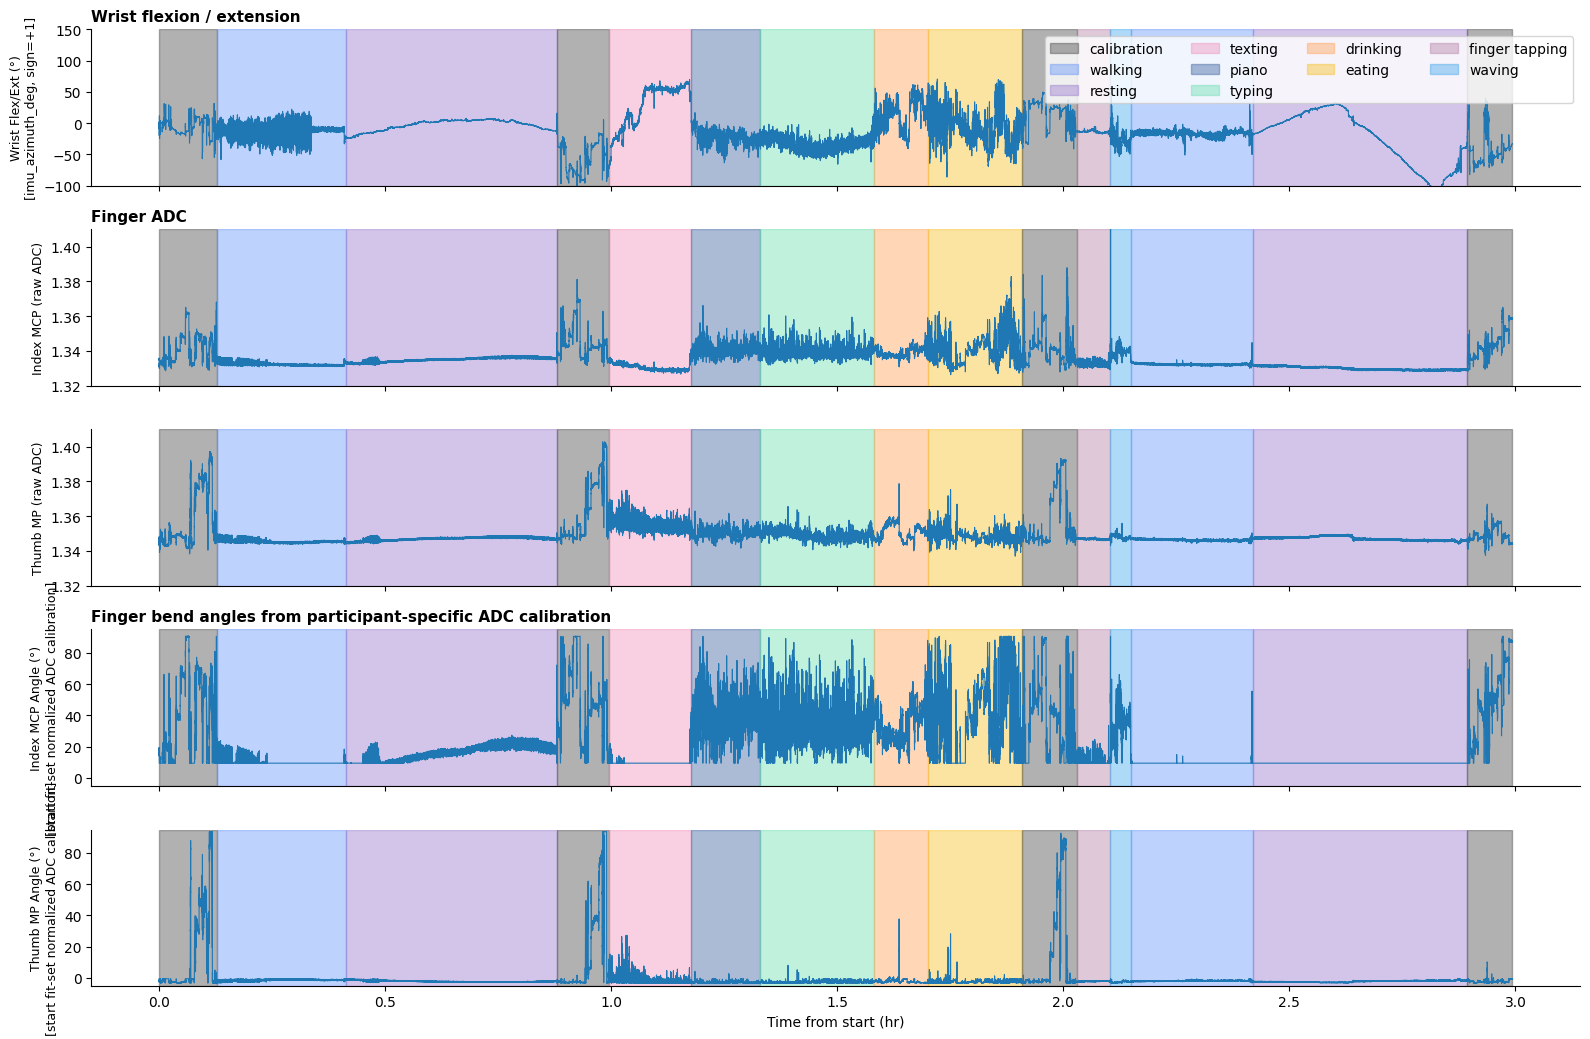

In [782]:
# cleaned plot with disconnects and label shading

plot_groups_final = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "Finger ADC": ["ADC_ch0", "ADC_ch1"],
    "Finger angles": ["index_mcp_deg", "thumb_mp_deg"],
}
plot_groups_final = {
    k: [c for c in v if c in df_final.columns]
    for k, v in plot_groups_final.items()
    if any(c in df_final.columns for c in v)
}

adc_ylim_map_final = {
    "wrist_flex_ext_deg": (-100, 150),
    "ADC_ch0": (1.32, 1.41),
    "ADC_ch1": (1.32, 1.41),
    "index_mcp_deg": (-5, 95),
    "thumb_mp_deg": (-5, 95),
}

plot_all_signals_one_figure(
    df_final,
    plot_groups_final,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map_final,
    xcol="elapsed_hr",
)

# activity analysis

In [783]:
# activity analysis — imports
from IPython.display import display
from long_term_wear_plotting import (
    build_activity_segments_df,
    print_label_table,
    plot_activity_window,
)

In [784]:
# activity analysis — print manual segments and note rows

activity_segments_df = build_activity_segments_df(manual_segments)

print("Manual activity segments")
print_label_table(manual_segments)
display(activity_segments_df)

print("\nRows with notes")
display(note_rows)

Manual activity segments
#     label           start (min)  end (min)      duration
----------------------------------------------------------
1     calibration           0.000      7.700    7 min 41 s
2     walking               7.700     24.772   17 min 04 s
3     resting              24.772     52.756   27 min 59 s
4     calibration          52.756     59.774    7 min 01 s
5     texting              59.774     70.616   10 min 50 s
6     piano                70.616     79.729    9 min 06 s
7     typing               79.729     94.899   15 min 10 s
8     drinking             94.899    101.988    7 min 05 s
9     eating              101.988    114.568   12 min 34 s
10    calibration         114.568    121.876    7 min 18 s
11    finger tapping      121.876    126.197    4 min 19 s
12    waving              126.197    128.923    2 min 43 s
13    walking             128.923    145.201   16 min 16 s
14    resting             145.201    173.596   28 min 23 s
15    calibration         173.5

,segment_id,label,start_min,end_min,duration_sec
0,1,calibration,0.000000,7.699932,461.99592
1,2,walking,7.699933,24.772416,1024.34898
2,3,resting,24.772417,52.755982,1679.01390
3,4,calibration,52.755983,59.774482,421.10994
4,5,texting,59.774483,70.616249,650.50596
5,6,piano,70.616250,79.728632,546.74292
6,7,typing,79.728633,94.898716,910.20498
7,8,drinking,94.898717,101.987599,425.33292
8,9,eating,101.987600,114.567566,754.79796
9,10,calibration,114.567567,121.876416,438.53094



Rows with notes


,Timestamp,elapsed_min,elapsed_hr,Counter,Note
8470,2026-04-02 17:36:19+00:00,0.622517,0.010375,10587.0,calib
13202,2026-04-02 17:36:39.604000+00:00,0.965917,0.016099,12638.0,index 0
24043,2026-04-02 17:37:27.244000+00:00,1.759917,0.029332,17375.0,index 22.5
33952,2026-04-02 17:38:10.920000+00:00,2.487850,0.041464,21727.0,index 45
42663,2026-04-02 17:38:49.244000+00:00,3.126583,0.052110,25544.0,index 67.5
...,...,...,...,...,...
2361410,2026-04-02 20:31:10.745000+00:00,175.484933,2.924749,1053605.0,i 45
2384986,2026-04-02 20:32:53.191000+00:00,177.192367,2.953206,1063794.0,i 45
2393218,2026-04-02 20:33:28.833000+00:00,177.786400,2.963107,1067340.0,i 67.5
2406773,2026-04-02 20:34:27.365000+00:00,178.761933,2.979366,1073166.0,i 67.5


In [785]:
# zoom --> 4/2 
    # walking: 8.286050
    # resting: 52.029767
    # texting: 61.608050
    # piano: 74.448867
    # typing: 83.515217
    # eating: 112.035767

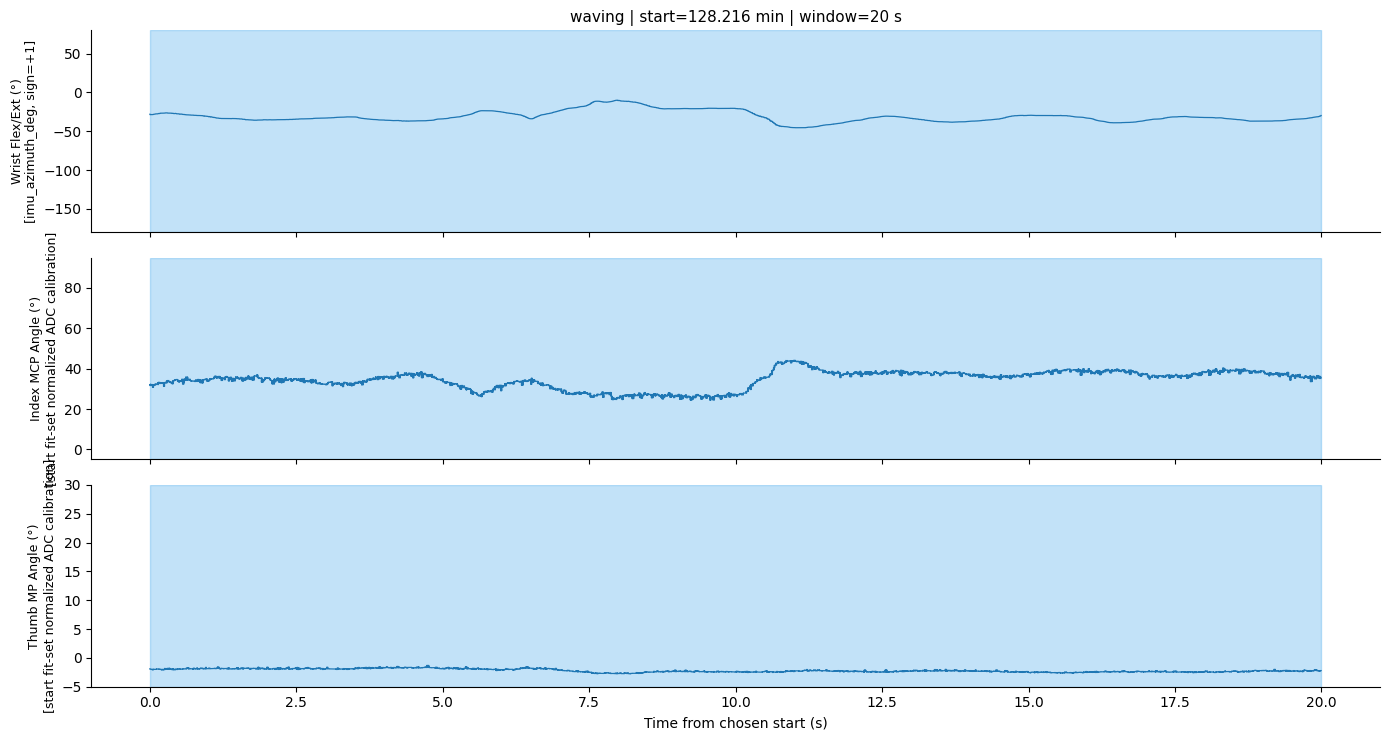

In [786]:
# inspect a zoomed activity window
# choose the start time in minutes and the amount of time to show in seconds

START_MIN = 128.215583				   # change me
WINDOW_SEC = 20          # change me

VIEW_MODE = "angles"     # "angles", "adc", or "both"

plot_col_options = {
    "angles": [
        "wrist_flex_ext_deg",
        "index_mcp_deg",
        "thumb_mp_deg",
    ],
    "adc": [
        "wrist_flex_ext_deg",
        "ADC_ch0",
        "ADC_ch1",
    ],
    "both": [
        "wrist_flex_ext_deg",
        "ADC_ch0",
        "index_mcp_deg",
        "ADC_ch1",
        "thumb_mp_deg",

    ],
}

analysis_cols = [
    c for c in plot_col_options[VIEW_MODE]
    if c in df_final.columns
]

activity_ylim_map = {
    "wrist_flex_ext_deg": (-180, 80),
    "index_mcp_deg": (-5, 95),
    "thumb_mp_deg": (-5, 30),
    "ADC_ch0": (1.32, 1.38),
    "ADC_ch1": (1.32, 1.38),
}

plot_activity_window(
    df_final,
    start_min=START_MIN,
    window_sec=WINDOW_SEC,
    columns=analysis_cols,
    manual_segments=manual_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    ylim_map=activity_ylim_map,
)

# figure making 

# fig 7 layout 1 with calib

In [787]:
import re
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

def plot_activity_window_final(
    df,
    activity_starts,
    *,
    columns=("wrist_flex_ext_deg", "index_mcp_deg", "thumb_mp_deg"),
    window_sec=20,
    display_name_map=None,
    ylim_map=None,
    label_colors=None,
    figsize=(14, 7),
):
    display_name_map = display_name_map or {}
    ylim_map = ylim_map or {}
    label_colors = label_colors or {}

    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(2, 3, wspace=0.08, hspace=0.18)

    for i, (activity, start_min) in enumerate(activity_starts.items()):
        row = i // 3
        col = i % 3

        inner = outer[row, col].subgridspec(3, 1, hspace=0.08)
        axes = [fig.add_subplot(inner[j, 0]) for j in range(3)]

        end_min = start_min + window_sec / 60.0
        df_win = df.loc[
            (df["elapsed_min"] >= start_min) &
            (df["elapsed_min"] <= end_min)
        ].copy()

        if df_win.empty:
            axes[1].text(0.5, 0.5, "No data", ha="center", va="center")
            continue

        df_win["window_sec"] = (df_win["elapsed_min"] - start_min) * 60.0

        for j, (ax, signal_col) in enumerate(zip(axes, columns)):
            shade_color = label_colors.get(activity, "lightgray")
            ax.axvspan(0, window_sec, color=shade_color, alpha=0.3, zorder=0)
            ax.plot(df_win["window_sec"], df_win[signal_col], linewidth=0.5, color="black", zorder=2)
            ax.set_xlim(0, window_sec)

            ax.xaxis.set_major_locator(MultipleLocator(5))
            ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
            ax.xaxis.set_minor_locator(MultipleLocator(2.5))

            if signal_col in ylim_map and ylim_map[signal_col] is not None:
                ax.set_ylim(*ylim_map[signal_col])

            if col == 0:
                ylabel = display_name_map.get(signal_col, signal_col)
                ylabel = re.sub(r"\s*\[.*?\]", "", ylabel)
                ax.set_ylabel(ylabel, fontsize=8)
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

            if row == 1 and j == 2:
                ax.set_xlabel("Time (s)", fontsize=8)
            elif j == 2:
                ax.tick_params(labelbottom=False)
            else:
                ax.tick_params(labelbottom=False)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", labelsize=8)


        axes[0].set_title(activity, fontsize=11, fontweight="bold")

    # fig.subplots_adjust(left=0.07, right=0.99, top=0.93, bottom=0.08)
    plt.show()

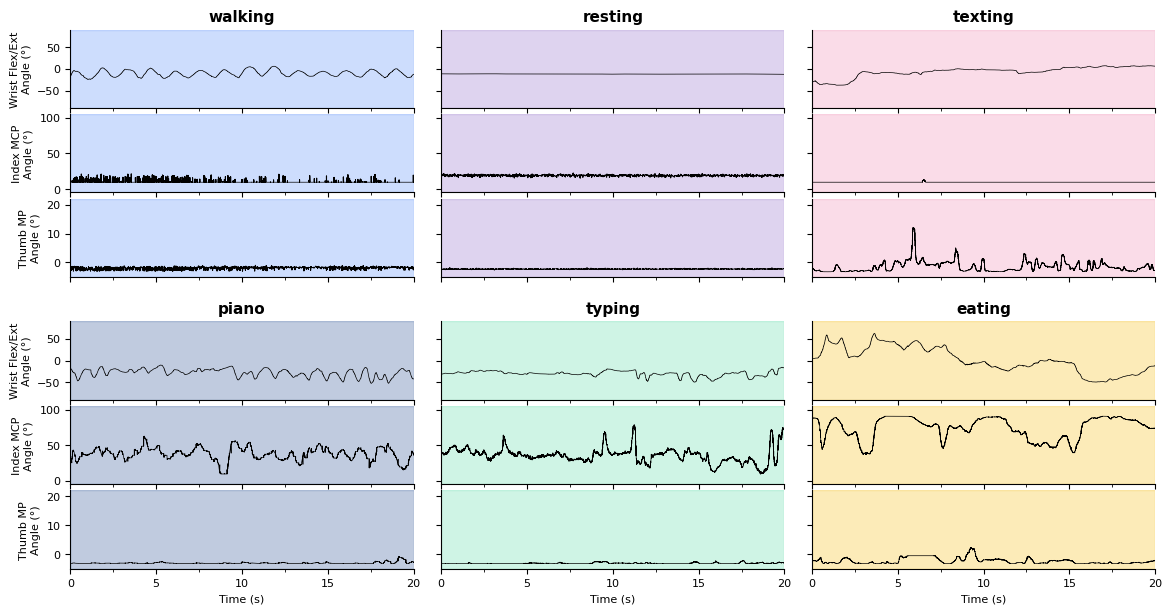

In [788]:
activity_starts = {
    "walking": 8.286050,
    "resting": 52.029767,
    "texting": 61.608050,
    "piano": 74.448867,
    "typing": 83.515217,
    "eating": 112.035767,
}

final_ylim_map = {
    "wrist_flex_ext_deg": (-90, 90),
    "index_mcp_deg": (-5, 105),
    "thumb_mp_deg": (-5, 22),
}

final_display_name_map = {
    "wrist_flex_ext_deg": "Wrist Flex/Ext\nAngle (°)",
    "index_mcp_deg": "Index MCP\nAngle (°)",
    "thumb_mp_deg": "Thumb MP\nAngle (°)",
}

plot_activity_window_final(
    df_final,
    activity_starts,
    display_name_map=final_display_name_map,
    ylim_map=final_ylim_map,
    label_colors=label_colors,
)

In [789]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, FuncFormatter
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from long_term_wear_plotting import _evaluate_adc_angle_model
def _plot_calibration_sets_on_axes(
    axes,
    df_raw,
    calib_spec_df,
    calib_summary_df,
    models,
    *,
    time_col="elapsed_min",
    normal=True,
    set_order=None,
    set_color_map=None,
):
    spec = calib_spec_df.copy()
    summ = calib_summary_df.copy()

    sensors_present = [s for s in ["index", "thumb"] if s in spec["sensor"].unique()]

    for ax, sensor in zip(axes, sensors_present):
        spec_sensor = spec[spec["sensor"] == sensor].copy()
        summ_sensor = summ[summ["sensor"] == sensor].copy()

        sensor_set_labels = [
            lbl for lbl in set_order
            if lbl in spec_sensor["set_label"].unique()
        ]

        for set_label in sensor_set_labels:
            color = set_color_map.get(set_label, None)
            curve_key = f"{sensor} | {set_label}"
            model = models.get(curve_key)

            spec_sub = spec_sensor[spec_sensor["set_label"] == set_label].sort_values("angle_deg")
            summ_sub = summ_sensor[summ_sensor["set_label"] == set_label].sort_values("angle_deg")

            raw_x_all = []
            raw_y_all = []

            for _, seg in spec_sub.iterrows():
                adc_col = seg["channel"]
                if adc_col not in df_raw.columns:
                    continue

                mask = (
                    (df_raw[time_col] >= float(seg["start_min"])) &
                    (df_raw[time_col] <= float(seg["end_min"]))
                )
                vals = pd.to_numeric(df_raw.loc[mask, adc_col], errors="coerce").dropna().to_numpy(float)

                if len(vals) == 0:
                    continue

                if normal and model is not None:
                    adc_min = float(model["adc_min"])
                    adc_max = float(model["adc_max"])
                    denom = adc_max - adc_min
                    vals = (vals - adc_min) / denom if denom != 0 else vals

                raw_x_all.append(np.full(len(vals), float(seg["angle_deg"])))
                raw_y_all.append(vals)

            if raw_x_all:
                ax.scatter(
                    np.concatenate(raw_x_all),
                    np.concatenate(raw_y_all),
                    s=5,
                    alpha=0.12,
                    color=color,
                    edgecolor="none",
                )

            if not summ_sub.empty and model is not None:
                mean_x = summ_sub["angle_deg"].to_numpy(float)
                mean_adc = summ_sub["adc_mean"].to_numpy(float)

                adc_min = float(model["adc_min"])
                adc_max = float(model["adc_max"])
                denom = adc_max - adc_min
                mean_y = (mean_adc - adc_min) / denom if normal and denom != 0 else mean_adc

                ax.scatter(mean_x, mean_y, s=18, color=color, edgecolor="none", zorder=3)

                adc_grid = np.linspace(adc_min, adc_max, 400)
                angle_grid = _evaluate_adc_angle_model(model, adc_grid, clip_normalized=False)
                y_grid = (adc_grid - adc_min) / denom if normal and denom != 0 else adc_grid

                ax.plot(angle_grid, y_grid, linewidth=1.2, color=color, alpha=0.5)

        cal_handles = [
            Patch(facecolor=set_color_map[label], edgecolor="none", label=label)
            for label in set_order
            if label in set_color_map
        ]

        if cal_handles:
            axes[-1].legend(
                handles=cal_handles,
                #title="Calibration set",
                loc="lower right",
                frameon=False,
                fontsize=7,
                title_fontsize=8,
                #alpha=0.5
            )

        ax.set_title(f"{sensor.capitalize()} Calibration", fontsize=9, fontweight="bold")
        ax.set_xlabel("Angle (°)", fontsize=8)
        ax.set_ylabel("Norm. ADC", fontsize=8)
        ax.tick_params(axis="both", labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


In [790]:
def plot_wear_summary_figure_final(
    df,
    activity_starts,
    *,
    columns=("wrist_flex_ext_deg", "index_mcp_deg", "thumb_mp_deg"),
    window_sec=20,
    manual_segments=None,
    label_colors=None,
    display_name_map=None,
    ylim_map=None,
    calibration_df_raw=None,
    manual_calibration_segments=None,
    all_calibration_data_df=None,
    calibration_models_by_set=None,
    set_order=None,
    set_color_map=None,
    figsize=(14, 11),
    save_path=None,
):
    manual_segments = manual_segments or []
    label_colors = label_colors or {}
    display_name_map = display_name_map or {}
    ylim_map = ylim_map or {}

    df = df.copy()
    if "elapsed_hr" not in df.columns:
        df["elapsed_hr"] = df["elapsed_min"] / 60.0

    def clean_label(col):
        return re.sub(r"\s*\[.*?\]", "", display_name_map.get(col, col))

    fig = plt.figure(figsize=figsize)

    main = fig.add_gridspec(
        2, 1,
        height_ratios=[1.25, 1.0],
        hspace=0.28
    )

    # ---------- TOP: 20 s bursts ----------
    top = main[0].subgridspec(2, 3, wspace=0.10, hspace=0.20)

    for i, (activity, start_min) in enumerate(activity_starts.items()):
        row = i // 3
        col = i % 3

        inner = top[row, col].subgridspec(3, 1, hspace=0.08)
        axes = [fig.add_subplot(inner[j, 0]) for j in range(3)]

        df_win = df[
            (df["elapsed_min"] >= start_min) &
            (df["elapsed_min"] <= start_min + window_sec / 60.0)
        ].copy()

        df_win["window_sec"] = (df_win["elapsed_min"] - start_min) * 60.0
        shade_color = label_colors.get(activity, "lightgray")

        for j, (ax, signal_col) in enumerate(zip(axes, columns)):
            ax.axvspan(0, window_sec, color=shade_color, alpha=0.30, zorder=0)
            ax.plot(df_win["window_sec"], df_win[signal_col], color="black", linewidth=0.5, zorder=2)

            ax.set_xlim(0, window_sec)
            ax.xaxis.set_major_locator(MultipleLocator(5))
            ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
            ax.xaxis.set_minor_locator(MultipleLocator(2.5))

            if signal_col in ylim_map:
                ax.set_ylim(*ylim_map[signal_col])

            if col == 0:
                ax.set_ylabel(clean_label(signal_col), fontsize=8)
            else:
                ax.tick_params(labelleft=False)

            if row == 1 and j == 2:
                ax.set_xlabel("Time (s)", fontsize=8)
            else:
                ax.tick_params(labelbottom=False)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(axis="both", labelsize=7)

        axes[0].set_title(activity.capitalize(), fontsize=10, fontweight="bold")

    # ---------- BOTTOM: long wear + calibration ----------
    bottom = main[1].subgridspec(
        1, 3,
        width_ratios=[1.15, 1.15, 0.55],
        wspace=0.18
    )

    long_grid = bottom[0, :2].subgridspec(3, 1, hspace=0.08)
    long_axes = [fig.add_subplot(long_grid[j, 0]) for j in range(3)]

    for j, (ax, signal_col) in enumerate(zip(long_axes, columns)):
        for seg in manual_segments:
            ax.axvspan(
                seg["start_min"] / 60.0,
                seg["end_min"] / 60.0,
                color=label_colors.get(seg["label"], "lightgray"),
                alpha=0.30,
                zorder=0,
            )

        ax.plot(df["elapsed_hr"], df[signal_col], color="black", linewidth=0.5, zorder=2)
        ax.set_xlim(0, 3.0)
        ax.margins(x=0)

        if signal_col in ylim_map:
            ax.set_ylim(*ylim_map[signal_col])

        ax.set_ylabel(clean_label(signal_col), fontsize=8)

        ax.xaxis.set_major_locator(MultipleLocator(0.5))       # labels every 30 min
        ax.xaxis.set_minor_locator(MultipleLocator(1 / 6))     # ticks every 10 min
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))

        if j < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("Time (hr)", fontsize=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=7)

    long_axes[0].set_title("3-hour Wear Session", fontsize=10, fontweight="bold", loc="left")

    # Legend under long-wear plot
    legend_handles = [
        Patch(facecolor=color, edgecolor="none", alpha=0.30, label=label)
        for label, color in label_colors.items()
        if any(seg["label"] == label for seg in manual_segments)
    ]

    if legend_handles:
        long_axes[0].legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.18),
            ncol=5,
            frameon=False,
            fontsize=8,
        )

    # Calibration curves on right
    cal_grid = bottom[0, 2].subgridspec(2, 1, hspace=0.45)
    cal_axes = [fig.add_subplot(cal_grid[j, 0]) for j in range(2)]

    if calibration_df_raw is not None:
        _plot_calibration_sets_on_axes(
            cal_axes,
            calibration_df_raw,
            manual_calibration_segments,
            all_calibration_data_df,
            calibration_models_by_set,
            normal=True,
            set_order=set_order,
            set_color_map=set_color_map,
        )

    if save_path is not None:
        fig.savefig(save_path, format="pdf", bbox_inches="tight")

    fig.subplots_adjust(left=0.07, right=0.98, top=0.96, bottom=0.10)
    plt.show()

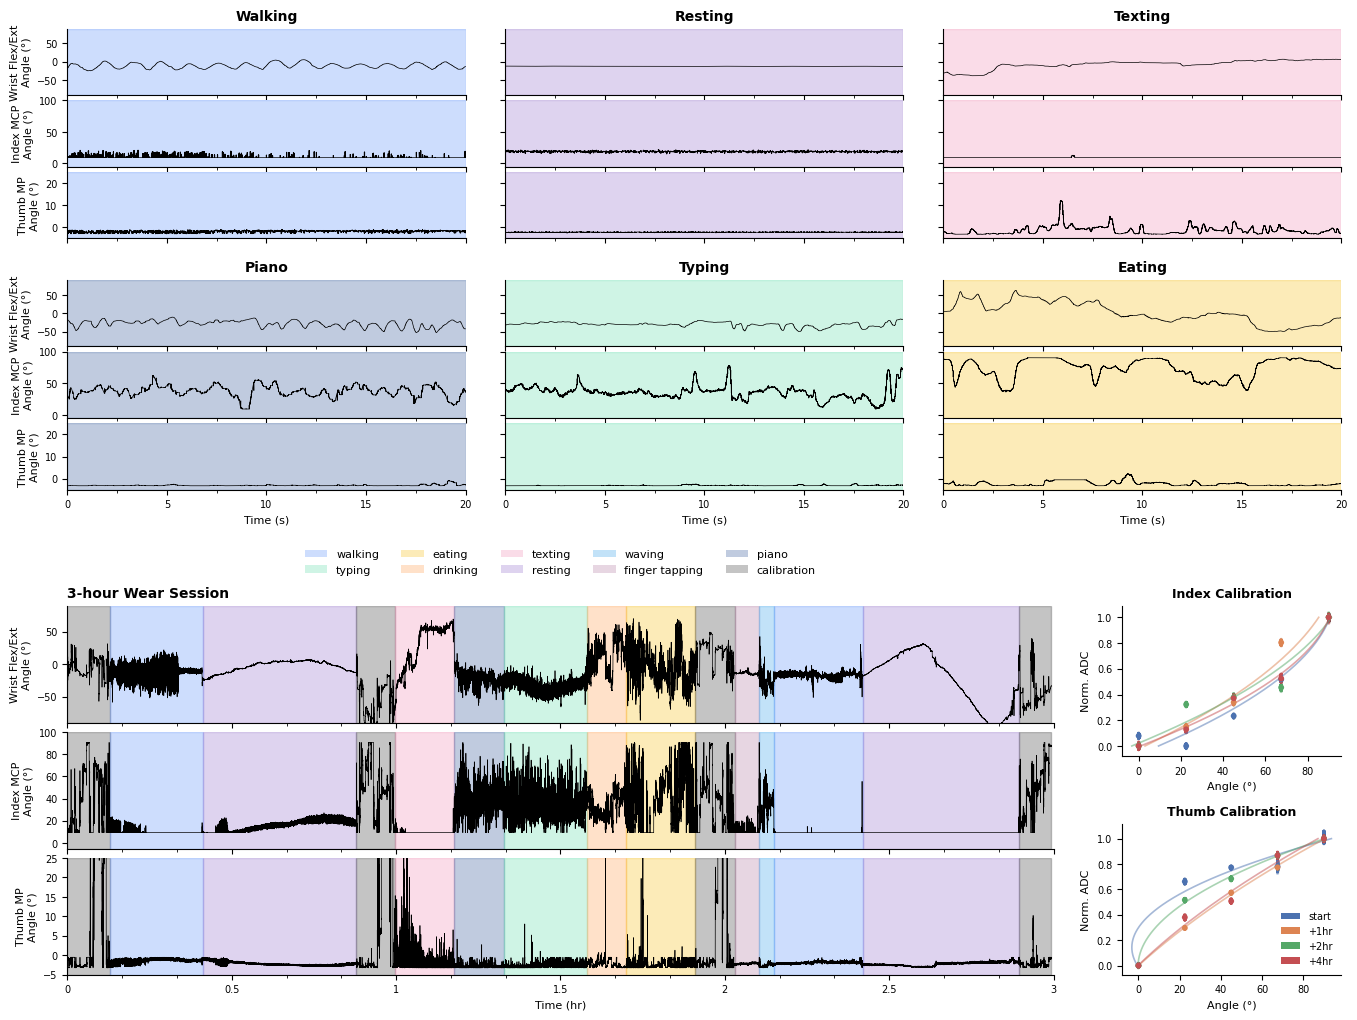

In [791]:
final_display_name_map = {
    "wrist_flex_ext_deg": "Wrist Flex/Ext\nAngle (°)",
    "index_mcp_deg": "Index MCP\nAngle (°)",
    "thumb_mp_deg": "Thumb MP\nAngle (°)",
}

ylim_map_final = {
    "wrist_flex_ext_deg": (-90, 90),
    "index_mcp_deg": (-5, 100),
    "thumb_mp_deg": (-5, 25),
}

plot_wear_summary_figure_final(
    df_final,
    activity_starts,
    manual_segments=manual_segments,
    label_colors=label_colors,
    display_name_map=final_display_name_map,
    ylim_map=ylim_map_final,
    calibration_df_raw=calibration_df_raw,
    manual_calibration_segments=manual_calibration_segments,
    all_calibration_data_df=all_calibration_data_df,
    calibration_models_by_set=calibration_models_by_set,
    set_order=SET_ORDER,
    set_color_map=SET_COLOR_MAP,
    save_path="wear_summary_figure.pdf",
)

# fig 7 alt layout no calib

In [792]:
def plot_wear_summary_figure_final_alt(
    df,
    activity_starts,
    *,
    columns=("wrist_flex_ext_deg", "index_mcp_deg", "thumb_mp_deg"),
    window_sec=20,
    manual_segments=None,
    label_colors=None,
    display_name_map=None,
    ylim_map=None,
    figsize=(8, 6.5),
    save_path=None,
):
    manual_segments = manual_segments or []
    label_colors = label_colors or {}
    display_name_map = display_name_map or {}
    ylim_map = ylim_map or {}

    df = df.copy()
    if "elapsed_hr" not in df.columns:
        df["elapsed_hr"] = df["elapsed_min"] / 60.0

    def clean_label(col):
        return re.sub(r"\s*\[.*?\]", "", display_name_map.get(col, col))

    def plot_20s_panel(parent_grid, activity_order, show_xlabel):
        grid = parent_grid.subgridspec(1, 3, wspace=0.16)

        for i, activity in enumerate(activity_order):
            start_min = activity_starts[activity]

            inner = grid[0, i].subgridspec(3, 1, hspace=0.08)
            axes = [fig.add_subplot(inner[j, 0]) for j in range(3)]

            df_win = df[
                (df["elapsed_min"] >= start_min) &
                (df["elapsed_min"] <= start_min + window_sec / 60.0)
            ].copy()

            df_win["window_sec"] = (df_win["elapsed_min"] - start_min) * 60.0
            shade_color = label_colors.get(activity, "lightgray")

            for j, (ax, signal_col) in enumerate(zip(axes, columns)):
                ax.axvspan(0, window_sec, color=shade_color, alpha=0.30, zorder=0)
                ax.plot(df_win["window_sec"], df_win[signal_col], color="black", linewidth=0.5, zorder=2)

                ax.set_xlim(0, window_sec)
                ax.xaxis.set_major_locator(MultipleLocator(5))
                ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
                ax.xaxis.set_minor_locator(MultipleLocator(2.5))

                if signal_col in ylim_map:
                    ax.set_ylim(*ylim_map[signal_col])

                if signal_col == "index_mcp_deg":
                    ax.set_yticks([0, 45, 90])

                elif signal_col == "thumb_mp_deg":
                    ax.set_yticks([0, 10, 20])

                if i == 0:
                    ax.set_ylabel(clean_label(signal_col), fontsize=8)
                else:
                    ax.tick_params(labelleft=False)

                if show_xlabel and j == 2:
                    ax.set_xlabel("Time (s)", fontsize=8)
                else:
                    ax.tick_params(labelbottom=False)

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.tick_params(axis="both", labelsize=7)

            axes[0].set_title(activity.capitalize(), fontsize=10, fontweight="bold")

    fig = plt.figure(figsize=figsize)

    main = fig.add_gridspec(
        3, 1,
        height_ratios=[1.0, 1.25, 1.0],
        hspace=0.55,
    )

    # Top row
    plot_20s_panel(
        main[0],
        ["walking", "texting", "typing"],
        show_xlabel=False,
    )

    # Middle row: 3-hour wear session
    middle_outer = main[1].subgridspec(
        1, 2,
        width_ratios=[1.0, 0.2],
        wspace=0.01,
    )

    middle = middle_outer[0, 0].subgridspec(3, 1, hspace=0.08)
    long_axes = [fig.add_subplot(middle[j, 0]) for j in range(3)]

    legend_ax = fig.add_subplot(middle_outer[0, 1])
    legend_ax.axis("off")

    for j, (ax, signal_col) in enumerate(zip(long_axes, columns)):
        for seg in manual_segments:
            ax.axvspan(
                seg["start_min"] / 60.0,
                seg["end_min"] / 60.0,
                color=label_colors.get(seg["label"], "lightgray"),
                alpha=0.30,
                zorder=0,
            )

        ax.plot(df["elapsed_hr"], df[signal_col], color="black", linewidth=0.3, zorder=2)

        ax.set_xlim(0, 3.0)
        ax.margins(x=0)

        if signal_col in ylim_map:
            ax.set_ylim(*ylim_map[signal_col])

        if signal_col == "index_mcp_deg":
            ax.set_yticks([0, 45, 90])
            ax.set_yticklabels(["0", "45", "90"])

        elif signal_col == "thumb_mp_deg":
            ax.set_yticks([0, 10, 20])
            ax.set_yticklabels(["0", "10", "20"])

        ax.set_ylabel(clean_label(signal_col), fontsize=8)

        ax.xaxis.set_major_locator(MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(MultipleLocator(1 / 6))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))

        if j < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("Time (hr)", fontsize=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=7)

    long_axes[0].set_title("3-hour Wear Session", fontsize=10, fontweight="bold", loc="left")

    segment_20s_labels = {
        "walking", "piano", "eating",
        "resting", "typing", "texting",
    }

    legend_handles = [
        Patch(facecolor=color, edgecolor="none", alpha=0.30, label=label.capitalize())
        for label, color in label_colors.items()
        if (
            label not in segment_20s_labels
            and any(seg["label"] == label for seg in manual_segments)
        )
    ]


    if legend_handles:
        legend_ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(0.0, 0.5),
            bbox_transform=legend_ax.transAxes,
            ncol=1,
            frameon=False,
            fontsize=8,
        )

    # Bottom row
    plot_20s_panel(
        main[2],
        ["resting", "piano", "eating"],
        show_xlabel=True,
    )

    fig.subplots_adjust(left=0.07, right=0.98, top=0.96, bottom=0.08)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, format="pdf", bbox_inches="tight")

    plt.show()

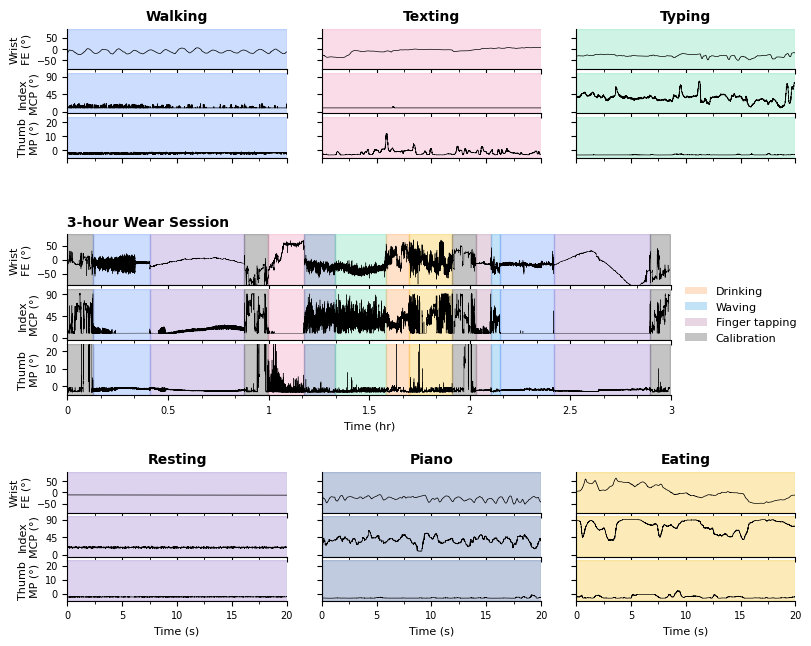

In [793]:
final_display_name_map = {
    "wrist_flex_ext_deg": "Wrist\nFE (°)",
    "index_mcp_deg": "Index\nMCP (°)",
    "thumb_mp_deg": "Thumb\nMP (°)",
}

ylim_map_final = {
    "wrist_flex_ext_deg": (-90, 90),
    "index_mcp_deg": (-5, 100),
    "thumb_mp_deg": (-5,24),
}

plot_wear_summary_figure_final_alt(
    df_final,
    activity_starts,
    manual_segments=manual_segments,
    label_colors=label_colors,
    display_name_map=final_display_name_map,
    ylim_map=ylim_map_final,
    save_path="wear_summary_figure_alt.pdf",
)

# supp battery long wear with calib

In [794]:
# Supplement: combine 3hr + battery files, then plot only the calibration blocks
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch
import re

COMBINED_SESSION_DATE = "2026_04_02"
COMBINED_FILE_PATTERNS = [
    "3hr_kinwatch_unified_*.csv",
    "battery_kinwatch_unified_*.csv",
]

# These are on the GLOBAL elapsed_min axis after the two files are combined by Timestamp.
combined_calibration_blocks = [
    {"start_min": 0.0,        "end_min": 7.699932,   "label": "calibration", "set_label": "start"},
    {"start_min": 52.755983,  "end_min": 59.774482,  "label": "calibration", "set_label": "+1hr"},
    {"start_min": 114.567567, "end_min": 121.876416, "label": "calibration", "set_label": "+2hr"},
    {"start_min": 250.336100, "end_min": 255.640183, "label": "calibration", "set_label": "+4hr"},
]

combined_data_dir = data_root / COMBINED_SESSION_DATE
combined_csv_paths = []

for pattern in COMBINED_FILE_PATTERNS:
    matches = sorted(combined_data_dir.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern} found in {combined_data_dir}")
    combined_csv_paths.append(matches[-1])

print("Using files, in order:")
for p in combined_csv_paths:
    print(" -", p.name)

combined_parts = []
for source_order, path in enumerate(combined_csv_paths):
    part = pd.read_csv(path)
    part["Timestamp"] = pd.to_datetime(part["Timestamp"], utc=True, errors="coerce")
    part = (
        part
        .dropna(subset=["Timestamp"])
        .sort_values("Timestamp")
        .reset_index(drop=True)
    )

    file_t0 = part["Timestamp"].iloc[0]
    part["elapsed_sec_file"] = (part["Timestamp"] - file_t0).dt.total_seconds()
    part["elapsed_min_file"] = part["elapsed_sec_file"] / 60.0
    part["source_file"] = path.name
    part["source_order"] = source_order
    combined_parts.append(part)

# Combine by real timestamps so the battery file keeps its true position on the shared time axis.
df_combined_raw = (
    pd.concat(combined_parts, ignore_index=True)
    .sort_values(["Timestamp", "source_order"])
    .reset_index(drop=True)
)

t0 = df_combined_raw["Timestamp"].iloc[0]
df_combined_raw["elapsed_sec"] = (df_combined_raw["Timestamp"] - t0).dt.total_seconds()
df_combined_raw["elapsed_min"] = df_combined_raw["elapsed_sec"] / 60.0
df_combined_raw["elapsed_hr"] = df_combined_raw["elapsed_sec"] / 3600.0

print("\nCombined time coverage by source file:")
display(
    df_combined_raw
    .groupby("source_file", sort=False)["elapsed_min"]
    .agg(start_min="min", end_min="max")
)

# ---------- clean obvious disconnect rows ----------
adc_disconnect_threshold_combined = globals().get("adc_disconnect_threshold", -1)

combined_adc0_disconnected_mask = (
    df_combined_raw["ADC_ch0"] < adc_disconnect_threshold_combined
    if "ADC_ch0" in df_combined_raw.columns else pd.Series(False, index=df_combined_raw.index)
)
combined_adc1_disconnected_mask = (
    df_combined_raw["ADC_ch1"] < adc_disconnect_threshold_combined
    if "ADC_ch1" in df_combined_raw.columns else pd.Series(False, index=df_combined_raw.index)
)

combined_imu2_disconnected_mask = (
    (df_combined_raw["IMU2_W"].abs() < 1e-6) &
    (df_combined_raw["IMU2_X"].abs() < 1e-6) &
    (df_combined_raw["IMU2_Y"].abs() < 1e-6) &
    (df_combined_raw["IMU2_Z"].abs() < 1e-6) &
    (df_combined_raw["IMU2_P"].abs() < 1e-6) &
    (df_combined_raw["IMU2_R"].abs() < 1e-6) &
    ((df_combined_raw["IMU2_H"] - 360).abs() < 1e-6)
)

df_combined_plot = df_combined_raw.copy()
if "ADC_ch0" in df_combined_plot.columns:
    df_combined_plot.loc[combined_adc0_disconnected_mask, "ADC_ch0"] = np.nan
if "ADC_ch1" in df_combined_plot.columns:
    df_combined_plot.loc[combined_adc1_disconnected_mask, "ADC_ch1"] = np.nan

imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
for col in imu2_cols:
    if col in df_combined_plot.columns:
        df_combined_plot.loc[combined_imu2_disconnected_mask, col] = np.nan

# ---------- derive final plotted angle columns ----------
if "participant_calib_models" not in globals():
    raise NameError("Run the participant calibration model fitting cells before this final combined plot cell.")

df_combined_final = df_combined_plot.copy()

df_combined_final = add_wrist_flex_ext_from_imus(
    df_combined_final,
    fe_source_col=globals().get("FE_SOURCE_COL", "imu_azimuth_deg"),
    out_col="wrist_flex_ext_deg",
    sign=globals().get("SIGN", 1.0),
    zero_baseline=globals().get("ZERO_BASELINE", True),
    baseline_window_sec=globals().get("BASELINE_WINDOW_SEC", 1.0),
    baseline_stat=globals().get("BASELINE_STAT", "median"),
)

if "wrist_flex_ext_deg" in df_combined_final.columns:
    df_combined_final.loc[combined_imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

df_combined_final = apply_adc_angle_models(
    df_combined_final,
    participant_calib_models,
    output_col_map=globals().get(
        "CALIB_OUTPUT_COL_MAP",
        {"index": "index_mcp_deg", "thumb": "thumb_mp_deg"},
    ),
    clamp=False,
    clamp_range_map=globals().get(
        "CALIB_CLAMP_RANGE_MAP",
        {"index": (0.0, 90.0), "thumb": (0.0, 90.0)},
    ),
)


Using files, in order:
 - 3hr_kinwatch_unified_20260402_103541.csv
 - battery_kinwatch_unified_20260402_133548.csv


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/1748619906.py:35: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  part = pd.read_csv(path)
/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/1748619906.py:35: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  part = pd.read_csv(path)



Combined time coverage by source file:


,start_min,end_min
source_file,,
3hr_kinwatch_unified_20260402_103541.csv,0.000000,179.586817
battery_kinwatch_unified_20260402_133548.csv,180.113083,538.897933


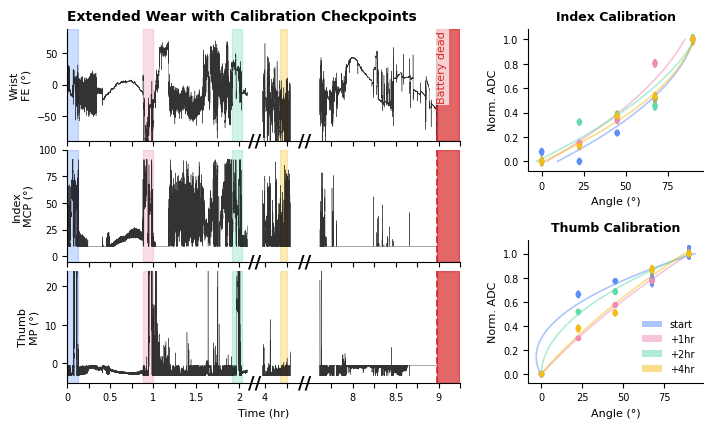

In [795]:
# -------------------------
# Colors: match activity colors
# -------------------------
SET_ORDER = ["start", "+1hr", "+2hr", "+4hr"]

SET_COLOR_MAP = {
    "start": label_colors["walking"],
    "+1hr": label_colors["texting"],
    "+2hr": label_colors["typing"],
    "+4hr": label_colors["eating"],
}

calib_colors = SET_COLOR_MAP

BATTERY_DIED_LABEL = "Battery dead"
BATTERY_DIED_COLOR = "#D62728"

data_end_original_hr = df_combined_final["elapsed_hr"].max()
data_end_plot_hr = to_plot_hr(data_end_original_hr)
x_axis_end_hr = to_plot_hr(max_original_hr)

# -------------------------
# x-axis gaps
# -------------------------
SHOW_TIME_GAPS = True

TIME_GAPS = [
    {"start": 2.1, "end": 3.95, "display_width": 0.15},
    {"start": 4.3, "end": 7.6, "display_width": 0.32},
]

RIGHT_PAD_HR = 0.25

df_plot = df_combined_final.copy()

def in_any_gap(t):
    return any(g["start"] <= t <= g["end"] for g in TIME_GAPS)

if SHOW_TIME_GAPS:
    df_plot = df_plot[~df_plot["elapsed_hr"].apply(in_any_gap)].copy()

    def to_plot_hr(t):
        shift = 0
        for g in TIME_GAPS:
            hidden_width = g["end"] - g["start"]
            compression = hidden_width - g["display_width"]

            if t > g["end"]:
                shift += compression
            elif t > g["start"]:
                shift += t - g["start"]

        return t - shift

    df_plot["elapsed_hr_plot"] = df_plot["elapsed_hr"].apply(to_plot_hr)

    gap_plot_spans = [
        (to_plot_hr(g["start"]), to_plot_hr(g["start"]) + g["display_width"])
        for g in TIME_GAPS
    ]
else:
    df_plot["elapsed_hr_plot"] = df_plot["elapsed_hr"]

    def to_plot_hr(t):
        return t

    gap_plot_spans = []

# -------------------------
# Figure layout: left 3x1 long trace, right 2x1 calibration curves
# -------------------------
fig = plt.figure(figsize=(8.2, 4.6))

outer = fig.add_gridspec(
    1, 2,
    width_ratios=[2.25, 1.0],
    wspace=0.24,
)

left_grid = outer[0, 0].subgridspec(3, 1, hspace=0.08)
long_axes = [fig.add_subplot(left_grid[j, 0]) for j in range(3)]

right_grid = outer[0, 1].subgridspec(2, 1, hspace=0.48)
cal_axes = [fig.add_subplot(right_grid[j, 0]) for j in range(2)]

columns = [
    "wrist_flex_ext_deg",
    "index_mcp_deg",
    "thumb_mp_deg",
]
columns = [c for c in columns if c in df_combined_final.columns]

# force useful original-time ticks
max_original_hr = df_combined_final["elapsed_hr"].max() + RIGHT_PAD_HR
tick_original = np.arange(0, np.ceil(max_original_hr * 4) / 4 + 0.001, 0.25)
tick_original = np.unique(np.r_[tick_original, [2.0, 4.0, 7.0]])
tick_original = np.array([t for t in tick_original if not in_any_gap(t)])

tick_plot = np.array([to_plot_hr(t) for t in tick_original])

tick_labels = []
for t in tick_original:
    if np.isclose(t % 1, 0) or np.isclose(t % 1, 0.5):
        tick_labels.append(f"{t:g}")
    else:
        tick_labels.append("")

for j, (ax, signal_col) in enumerate(zip(long_axes, columns)):

    # calibration block shading
    for seg in calib_segments:
        start_hr = seg["start_min"] / 60.0
        end_hr = seg["end_min"] / 60.0

        if in_any_gap(start_hr) and in_any_gap(end_hr):
            continue

        ax.axvspan(
            to_plot_hr(start_hr),
            to_plot_hr(end_hr),
            color=calib_colors[seg["label"]],
            alpha=0.30,
            zorder=0,
        )

    # battery died shading
    ax.axvspan(
        data_end_plot_hr,
        x_axis_end_hr,
        color=BATTERY_DIED_COLOR,
        alpha=0.70,
        zorder=0,
    )

    ax.plot(
        df_plot["elapsed_hr_plot"],
        df_plot[signal_col],
        color="black",
        linewidth=0.3,
        alpha=0.8,
        zorder=2,
    )

    # battery died event marker, formatted like disconnect markers
    ax.axvline(
        data_end_plot_hr,
        color=BATTERY_DIED_COLOR,
        linestyle="--",
        linewidth=1.3,
        alpha=0.95,
        zorder=4,
    )

    if j ==0: 
        ax.text(
            data_end_plot_hr,
            0.98,
            BATTERY_DIED_LABEL,
            rotation=90,
            color=BATTERY_DIED_COLOR,
            fontsize=8,
            ha="left",
            va="top",
            transform=ax.get_xaxis_transform(),
            zorder=5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.2),
        )

    # white gap overlays + ellipses, no vertical lines
    for gap_start_plot, gap_end_plot in gap_plot_spans:
        ax.axvspan(
            gap_start_plot,
            gap_end_plot,
            color="white",
            zorder=3,
        )

        ax.text(
            (gap_start_plot + gap_end_plot) / 2,
            0.08,
            "//",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=13,
            fontweight="bold",
            zorder=5,
            clip_on=False,
        )

    ax.set_xlim(0, x_axis_end_hr)
    ax.set_xticks(tick_plot)
    ax.set_xticklabels(tick_labels)

    if signal_col in ylim_map_final:
        ax.set_ylim(*ylim_map_final[signal_col])

    ax.set_ylabel(clean_label(signal_col), fontsize=8)

    if j < len(columns) - 1:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel("Time (hr)", fontsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=7)

long_axes[0].set_title(
    "Extended Wear with Calibration Checkpoints",
    fontsize=10,
    fontweight="bold",
    loc="left",
)

# -------------------------
# Calibration curves on right
# -------------------------
_plot_calibration_sets_on_axes(
    cal_axes,
    calibration_df_raw,
    manual_calibration_segments,
    all_calibration_data_df,
    calibration_models_by_set,
    normal=True,
    set_order=SET_ORDER,
    set_color_map=SET_COLOR_MAP,
)

# ensure only bottom-right legend on thumb calibration plot
if cal_axes[0].get_legend() is not None:
    cal_axes[0].get_legend().remove()

cal_axes[1].legend(
    handles=[
        Patch(facecolor=SET_COLOR_MAP[label], lw=2, label=label, alpha=0.5)
        for label in SET_ORDER
    ],
    loc="lower right",
    frameon=False,
    fontsize=7,
)

# save as PDF#
#fig_out = session_dir / "extended_wear_calibration_checkpoints.pdf"

fig.savefig(
    "extended_wear_calibration_checkpoints.pdf",
    format="pdf",
    bbox_inches="tight",
)

#print(f"Saved: {fig_out}")
plt.show()

# Supp disconnections

In [825]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, FuncFormatter
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

DISCONNECT_FIG_COLUMNS = [
    "wrist_flex_ext_deg",
    "index_mcp_deg",
    "thumb_mp_deg",
]

disconnect_display_name_map = {
    "wrist_flex_ext_deg": "Wrist\nFE (°)",
    "ADC_ch0": "Index MCP\nADC value",
    "ADC_ch1": "Thumb MP\nADC value",
}

disconnect_ylim_map = {
    "wrist_flex_ext_deg": (-90, 90),
    "index_mcp_deg": (-5, 100),
    "thumb_mp_deg": (-5, 24),
    "ADC_ch0": "Index MCP\nADC value",
    "ADC_ch1": "Thumb MP\nADC value",
}

disconnect_colors = {
    "index disconnect": "#4C72B0",
    "thumb disconnect": "#DD8452",
    "IMU2 disconnect": "#55A868",
    "bluetooth down": "#8172B2",
    "battery dying": "#C44E52",
}

# windows to show from each file
disconnect_windows = [
    {
        "key": "disconnect_file",
        "title": "Short sensor disconnects",
        "start_min": 0.0,
        "end_min": 10.0,   # can go down to 2.6
    },
    {
        "key": "sixhr_file",
        "title": "Bluetooth down",
        "start_min": 120.0,
        "end_min": 160.0,
    },
    {
        "key": "battery_file",
        "title": "Battery dying",
        "start_min": 132.0,   # 2.2 hr = 132 min
        "end_min": None,      # to end of file
    },
]

In [953]:
SHORT_EVENT_HALF_WIDTH_SEC = 2.0
SHORT_EVENT_HALF_WIDTH_MIN = SHORT_EVENT_HALF_WIDTH_SEC / 60.0

disconnect_events = {
    "disconnect_file": [
        {
            "label": "index sensor disconnected",
            "start_min": 0.69 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   0.69 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["index_mcp_deg"],
        },
        {
            "label": "index sensor disconnected",
            "start_min": 0.97 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   0.97 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["index_mcp_deg"],
        },
        {
            "label": "thumb sensor disconnected",
            "start_min": 1.24 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   1.24 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["thumb_mp_deg"],
        },
        {
            "label": "thumb sensor disconnected",
            "start_min": 1.50 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   1.50 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["thumb_mp_deg"],
        },
        {
            "label": "HB IMU disconnected",
            "start_min": 1.84 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   1.84 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["wrist_flex_ext_deg"],
        },
        {
            "label": "HB IMU disconnected",
            "start_min": 2.33 - SHORT_EVENT_HALF_WIDTH_MIN,
            "end_min":   2.33 + SHORT_EVENT_HALF_WIDTH_MIN,
            "signals": ["wrist_flex_ext_deg"],
        },
    ],
    "sixhr_file": [
        {
            "label": "bluetooth disconnected",
            "start_min": 122.0,
            "end_min": 148.0,
            "signals": DISCONNECT_FIG_COLUMNS,
        },
    ],
    "battery_file": [
        {
            "label": "low power",
            "start_min": 152.0,
            "end_min": None,   # to end of plotted battery window
            "signals": DISCONNECT_FIG_COLUMNS,
        },
    ],
}

In [954]:
# get dfs
# build prepared / cleaned dataframes for the disconnect-example figure
# assumes you already ran the earlier calibration/model cells, so these exist:
# - data_root
# - participant_calib_models
# - CALIB_OUTPUT_COL_MAP
# - CALIB_CLAMP_RANGE_MAP
# - FE_SOURCE_COL, SIGN, ZERO_BASELINE, BASELINE_WINDOW_SEC, BASELINE_STAT
# - adc_disconnect_threshold
# - gap_threshold_sec

from pathlib import Path
import pandas as pd
import numpy as np


def load_prepare_disconnect_figure_df(
    *,
    session_date,
    file_pattern,
    apply_angle_calibration=True,
    verbose=True,
):
    """
    Load one unified wear CSV and apply the same cleaning pipeline used earlier:
      1) timestamp parsing + elapsed time columns
      2) ADC disconnect detection + masking
      3) IMU2 disconnect detection + masking
      4) bluetooth-gap detection
      5) wrist FE derivation
      6) ADC -> angle calibration

    Returns a dict with:
      raw_df
      plot_df
      final_df
      adc0_disconnected_mask
      adc1_disconnected_mask
      imu2_disconnected_mask
      bluetooth_segments
      adc_disconnect_segments
      imu2_disconnect_segments
      csv_path
    """
    data_dir = data_root / session_date
    csv_files = sorted(data_dir.glob(file_pattern))
    if not csv_files:
        raise FileNotFoundError(f"No files matching {file_pattern} found in {data_dir}")

    csv_path = csv_files[-1]
    if verbose:
        print(f"\nUsing file: {csv_path.name}")

    df = pd.read_csv(csv_path)

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

    t0 = df["Timestamp"].iloc[0]
    df["elapsed_sec"] = (df["Timestamp"] - t0).dt.total_seconds()
    df["elapsed_min"] = df["elapsed_sec"] / 60.0
    df["elapsed_hr"] = df["elapsed_sec"] / 3600.0

    # -------------------------
    # detect ADC disconnects
    # -------------------------
    adc0_disconnected_mask = (
        df["ADC_ch0"] < adc_disconnect_threshold
        if "ADC_ch0" in df.columns else pd.Series(False, index=df.index)
    )
    adc1_disconnected_mask = (
        df["ADC_ch1"] < adc_disconnect_threshold
        if "ADC_ch1" in df.columns else pd.Series(False, index=df.index)
    )

    adc0_disconnect_segments = mask_to_segments(df, adc0_disconnected_mask, "sensor disconnected")
    for seg in adc0_disconnect_segments:
        seg["channel"] = "ADC_ch0"

    adc1_disconnect_segments = mask_to_segments(df, adc1_disconnected_mask, "sensor disconnected")
    for seg in adc1_disconnect_segments:
        seg["channel"] = "ADC_ch1"

    # -------------------------
    # detect IMU2 disconnects
    # -------------------------
    imu2_disconnected_mask = (
        (df["IMU2_W"].abs() < 1e-6) &
        (df["IMU2_X"].abs() < 1e-6) &
        (df["IMU2_Y"].abs() < 1e-6) &
        (df["IMU2_Z"].abs() < 1e-6) &
        (df["IMU2_P"].abs() < 1e-6) &
        (df["IMU2_R"].abs() < 1e-6) &
        ((df["IMU2_H"] - 360).abs() < 1e-6)
    )

    imu2_disconnect_segments = mask_to_segments(df, imu2_disconnected_mask, "IMU2 disconnected")

    # -------------------------
    # detect bluetooth-down gaps
    # -------------------------
    df["dt_sec"] = df["Timestamp"].diff().dt.total_seconds()
    gap_rows = df[df["dt_sec"] > gap_threshold_sec].copy()

    bluetooth_segments = []
    for idx in gap_rows.index:
        if idx == 0:
            continue

        prev_imu2_disc = bool(imu2_disconnected_mask.iloc[idx - 1])
        curr_imu2_disc = bool(imu2_disconnected_mask.iloc[idx])

        if prev_imu2_disc or curr_imu2_disc:
            continue

        bluetooth_segments.append({
            "start_min": float(df.loc[idx - 1, "elapsed_min"]),
            "end_min": float(df.loc[idx, "elapsed_min"]),
            "label": "bluetooth down",
            "gap_sec": float(df.loc[idx, "dt_sec"]),
            "start_time": df.loc[idx - 1, "Timestamp"],
            "end_time": df.loc[idx, "Timestamp"],
        })

    # -------------------------
    # clean up auto-detected segments
    # match your current notebook logic
    # -------------------------
    adc0_disconnect_segments = merge_close_segments(adc0_disconnect_segments, max_gap_min=0.002)
    adc1_disconnect_segments = merge_close_segments(adc1_disconnect_segments, max_gap_min=0.002)
    imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.002)
    bluetooth_segments = merge_close_segments(bluetooth_segments, max_gap_min=0.01)

    adc0_disconnect_segments = drop_tiny_segments(adc0_disconnect_segments, min_duration_min=0.0005)
    adc1_disconnect_segments = drop_tiny_segments(adc1_disconnect_segments, min_duration_min=0.0005)
    imu2_disconnect_segments = drop_tiny_segments(imu2_disconnect_segments, min_duration_min=0.002)
    bluetooth_segments = drop_tiny_segments(bluetooth_segments, min_duration_min=0.002)

    # your stricter IMU2 display cleanup
    imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.002)
    imu2_disconnect_segments = keep_min_duration_segments(imu2_disconnect_segments, min_duration_min=0.002)

    adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
    adc_disconnect_segments = sorted(adc_disconnect_segments, key=lambda s: s["start_min"])
    adc_disconnect_segments = merge_close_segments(adc_disconnect_segments, max_gap_min=0.002)

    # -------------------------
    # mask raw disconnected channels
    # -------------------------
    df_plot = df.copy()

    if "ADC_ch0" in df_plot.columns:
        df_plot.loc[adc0_disconnected_mask, "ADC_ch0"] = np.nan

    if "ADC_ch1" in df_plot.columns:
        df_plot.loc[adc1_disconnected_mask, "ADC_ch1"] = np.nan

    imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
    for col in imu2_cols:
        if col in df_plot.columns:
            df_plot.loc[imu2_disconnected_mask, col] = np.nan

    # -------------------------
    # derive wrist FE + apply ADC calibration
    # -------------------------
    df_final = df_plot.copy()

    df_final = add_wrist_flex_ext_from_imus(
        df_final,
        fe_source_col=FE_SOURCE_COL,
        out_col="wrist_flex_ext_deg",
        sign=SIGN,
        zero_baseline=ZERO_BASELINE,
        baseline_window_sec=BASELINE_WINDOW_SEC,
        baseline_stat=BASELINE_STAT,
    )

    if "wrist_flex_ext_deg" in df_final.columns:
        df_final.loc[imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

    if apply_angle_calibration:
        df_final = apply_adc_angle_models(
            df_final,
            participant_calib_models,
            output_col_map=CALIB_OUTPUT_COL_MAP,
            clamp=False,
            clamp_range_map=CALIB_CLAMP_RANGE_MAP,
        )

    if verbose:
        print(f"  duration: {df_final['elapsed_hr'].iloc[-1]:.2f} hr")
        print(f"  ADC_ch0 rows flagged: {int(adc0_disconnected_mask.sum())}")
        print(f"  ADC_ch1 rows flagged: {int(adc1_disconnected_mask.sum())}")
        print(f"  IMU2 rows flagged:    {int(imu2_disconnected_mask.sum())}")
        print(f"  bluetooth segments:   {len(bluetooth_segments)}")

    return {
        "csv_path": csv_path,
        "raw_df": df,
        "plot_df": df_plot,
        "final_df": df_final,
        "adc0_disconnected_mask": adc0_disconnected_mask,
        "adc1_disconnected_mask": adc1_disconnected_mask,
        "imu2_disconnected_mask": imu2_disconnected_mask,
        "bluetooth_segments": bluetooth_segments,
        "adc_disconnect_segments": adc_disconnect_segments,
        "imu2_disconnect_segments": imu2_disconnect_segments,
    }


# -------------------------
# build the three source dataframes for the figure
# -------------------------
disconnect_file_data = load_prepare_disconnect_figure_df(
    session_date="2026_03_18",
    file_pattern="disconnect_kinwatch_unified_*.csv",
)

sixhr_file_data = load_prepare_disconnect_figure_df(
    session_date="2026_03_05",
    file_pattern="6hr_kinwatch_unified_*.csv",
)

battery_file_data = load_prepare_disconnect_figure_df(
    session_date="2026_03_05",
    file_pattern="battery_kinwatch_unified_*.csv",
)

# convenient final dfs for plotting
df_disconnect_final = disconnect_file_data["final_df"]
df_6hr_final = sixhr_file_data["final_df"]
df_battery_final = battery_file_data["final_df"]

disconnect_df_map = {
    "disconnect_file": df_disconnect_final,
    "sixhr_file": df_6hr_final,
    "battery_file": df_battery_final,
}

print("\nFinal prepared dfs:")
for key, df_tmp in disconnect_df_map.items():
    print(f"  {key:16s} shape={df_tmp.shape}  duration_hr={df_tmp['elapsed_hr'].iloc[-1]:.2f}")


Using file: disconnect_kinwatch_unified_20260318_104546.csv
  duration: 0.04 hr
  ADC_ch0 rows flagged: 29
  ADC_ch1 rows flagged: 25
  IMU2 rows flagged:    873
  bluetooth segments:   0

Using file: 6hr_kinwatch_unified_20260305_113940.csv


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/1470169935.py:54: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/1470169935.py:54: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


  duration: 6.15 hr
  ADC_ch0 rows flagged: 0
  ADC_ch1 rows flagged: 216
  IMU2 rows flagged:    792
  bluetooth segments:   1

Using file: battery_kinwatch_unified_20260305_175417.csv
  duration: 3.89 hr
  ADC_ch0 rows flagged: 0
  ADC_ch1 rows flagged: 0
  IMU2 rows flagged:    0
  bluetooth segments:   0

Final prepared dfs:
  disconnect_file  shape=(33966, 45)  duration_hr=0.04
  sixhr_file       shape=(2972287, 45)  duration_hr=6.15
  battery_file     shape=(2023369, 45)  duration_hr=3.89


In [955]:
import pandas as pd
import numpy as np

def stack_files_continuously(
    df_list,
    *,
    file_labels=None,
    time_col="elapsed_min",
    new_time_col="elapsed_min_stacked",
    gap_min=0.02,
    add_nan_separator=True,
):
    stacked_parts = []
    file_bounds = []
    offset = 0.0

    all_cols = sorted(set().union(*[df.columns for df in df_list]))
    if file_labels is None:
        file_labels = [f"file_{i+1}" for i in range(len(df_list))]

    for i, (df, label) in enumerate(zip(df_list, file_labels)):
        if df is None or df.empty:
            continue
        if time_col not in df.columns:
            raise KeyError(f"Input dataframe {i} missing required column {time_col}")

        part = df.copy().sort_values(time_col).reset_index(drop=True)

        t0 = float(part[time_col].iloc[0])
        t1 = float(part[time_col].iloc[-1])

        part[new_time_col] = (part[time_col] - t0) + offset
        part["source_block"] = i + 1
        part["source_file_label"] = label
        stacked_parts.append(part)

        start_x = float(part[new_time_col].iloc[0])
        end_x = float(part[new_time_col].iloc[-1])

        file_bounds.append({
            "source_block": i + 1,
            "file_label": label,
            "orig_start_min": t0,
            "orig_end_min": t1,
            "stacked_start_min": start_x,
            "stacked_end_min": end_x,
            "duration_min": t1 - t0,
        })

        if add_nan_separator and i < len(df_list) - 1:
            sep_x = end_x + gap_min
            sep_row = {col: np.nan for col in all_cols}
            sep_row[new_time_col] = sep_x
            sep_row["source_block"] = np.nan
            sep_row["source_file_label"] = np.nan
            stacked_parts.append(pd.DataFrame([sep_row]))

        offset = end_x + gap_min

    df_stacked = pd.concat(stacked_parts, ignore_index=True, sort=False)
    bounds_df = pd.DataFrame(file_bounds)
    return df_stacked, bounds_df

In [956]:
df_disconnect_stacked, stacked_file_bounds = stack_files_continuously(
    [
        df_disconnect_final,   # 03/18 disconnect full file
        df_6hr_final,          # 03/05 6hr full file
        df_battery_final,      # 03/05 battery full file
    ],
    file_labels=[
        "disconnect_file",
        "sixhr_file",
        "battery_file",
    ],
    time_col="elapsed_min",
    new_time_col="elapsed_min_stacked",
    gap_min=0.05,   # 3 s visual gap between files
    add_nan_separator=True,
)

stacked_file_bounds

/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/778747077.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stacked = pd.concat(stacked_parts, ignore_index=True, sort=False)


,source_block,file_label,orig_start_min,orig_end_min,stacked_start_min,stacked_end_min,duration_min
0,1,disconnect_file,0.0,2.520033,0.000000,2.520033,2.520033
1,2,sixhr_file,0.0,368.999267,2.570033,371.569300,368.999267
2,3,battery_file,0.0,233.552200,371.619300,605.171500,233.552200


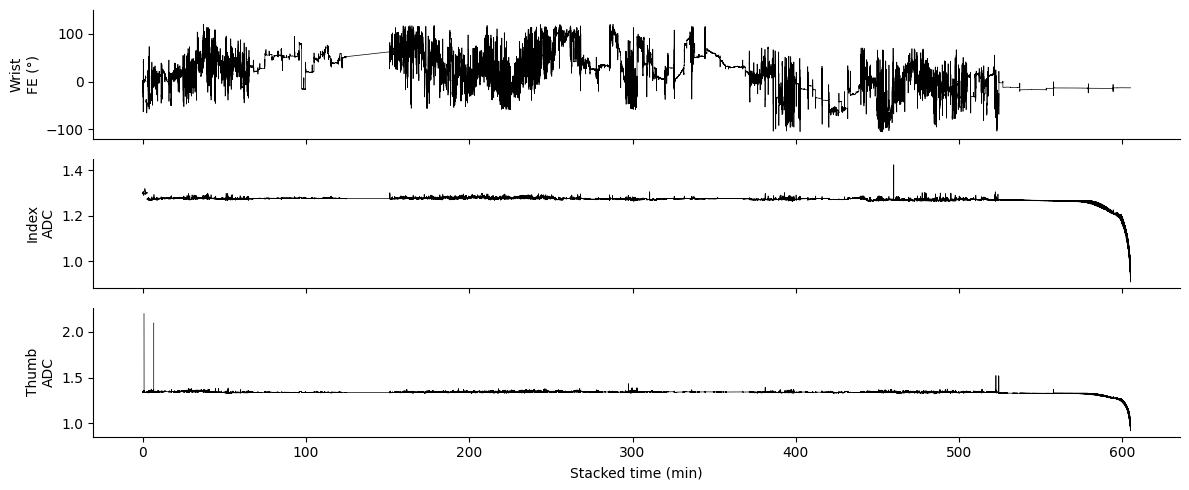

In [957]:
plot_cols = [
    "wrist_flex_ext_deg",
    "ADC_ch0",
    "ADC_ch1",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

for ax, col in zip(axes, plot_cols):
    ax.plot(
        df_disconnect_stacked["elapsed_min_stacked"],
        df_disconnect_stacked[col],
        color="black",
        linewidth=0.5,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if col == "wrist_flex_ext_deg":
        ax.set_ylabel("Wrist\nFE (°)")
        ax.set_ylim(-120, 150)
    
    elif col == "ADC_ch0":
        ax.set_ylabel("Index\nADC")
        #ax.set_ylim(-5, 100)
        #ax.set_yticks([0, 45, 90])

    elif col == "ADC_ch1":
        ax.set_ylabel("Thumb\nADC")
        #ax.set_ylim(-5, 24)
        #ax.set_yticks([0, 10, 20])

    elif col == "index_mcp_deg":
        ax.set_ylabel("Index\nMCP (°)")
        ax.set_ylim(-5, 100)
        ax.set_yticks([0, 45, 90])

    elif col == "thumb_mp_deg":
        ax.set_ylabel("Thumb\nMP (°)")
        ax.set_ylim(-5, 24)
        ax.set_yticks([0, 10, 20])

axes[-1].set_xlabel("Stacked time (min)")

plt.tight_layout()
plt.show()

In [958]:
SHORT_EVENT_HALF_WIDTH_SEC = 2.0
SHORT_EVENT_HALF_WIDTH_MIN = SHORT_EVENT_HALF_WIDTH_SEC / 60.0

disconnect_events = [
    # 03/18 disconnect file
    {
        "file_label": "disconnect_file",
        "label": "index sensor disconnected",
        "start_min": 0.69 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   0.69 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["ADC_ch1"],
    },
    {
        "file_label": "disconnect_file",
        "label": "index sensor disconnected",
        "start_min": 0.97 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   0.97 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["ADC_ch1"],
    },
    {
        "file_label": "disconnect_file",
        "label": "thumb sensor disconnected",
        "start_min": 1.24 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   1.24 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["ADC_ch0"],
    },
    {
        "file_label": "disconnect_file",
        "label": "thumb sensor disconnected",
        "start_min": 1.50 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   1.50 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["ADC_ch0"],
    },
    {
        "file_label": "disconnect_file",
        "label": "HB IMU disconnected",
        "start_min": 1.84 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   1.84 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["wrist_flex_ext_deg"],
    },
    {
        "file_label": "disconnect_file",
        "label": "HB IMU disconnected",
        "start_min": 2.33 - SHORT_EVENT_HALF_WIDTH_MIN,
        "end_min":   2.33 + SHORT_EVENT_HALF_WIDTH_MIN,
        "signals": ["wrist_flex_ext_deg"],
    },

    # 03/05 6hr
    {
        "file_label": "sixhr_file",
        "label": "bluetooth disconnected",
        "start_min": 122.0,
        "end_min": 148.0,
        "signals": ["wrist_flex_ext_deg", "ADC_ch0", "ADC_ch1"],
    },

    # 03/05 battery
    {
        "file_label": "battery_file",
        "label": "low power",
        "start_min": 152.0,
        "end_min": None,
        "signals": ["wrist_flex_ext_deg", "ADC_ch0", "ADC_ch1"],
    },
]

In [959]:
def convert_events_to_stacked_coords(events, stacked_file_bounds):
    """
    Convert per-file native elapsed_min events into stacked x coordinates.
    """
    out = []

    for ev in events:
        file_label = ev["file_label"]
        match = stacked_file_bounds[stacked_file_bounds["file_label"] == file_label]
        if match.empty:
            print(f"Skipping event, no file bound found for: {file_label}")
            continue

        row = match.iloc[0]
        orig_start = float(row["orig_start_min"])
        orig_end = float(row["orig_end_min"])
        stacked_start = float(row["stacked_start_min"])

        ev_start = float(ev["start_min"])
        ev_end = orig_end if ev["end_min"] is None else float(ev["end_min"])

        # map native file time -> stacked time
        stacked_x0 = (ev_start - orig_start) + stacked_start
        stacked_x1 = (ev_end   - orig_start) + stacked_start

        out.append({
            **ev,
            "stacked_start_min": stacked_x0,
            "stacked_end_min": stacked_x1,
        })

    return out


disconnect_events_stacked = convert_events_to_stacked_coords(
    disconnect_events,
    stacked_file_bounds,
)

pd.DataFrame(disconnect_events_stacked)

,file_label,label,start_min,end_min,signals,stacked_start_min,stacked_end_min
0,disconnect_file,index sensor disconnected,0.656667,0.723333,[ADC_ch1],0.656667,0.723333
1,disconnect_file,index sensor disconnected,0.936667,1.003333,[ADC_ch1],0.936667,1.003333
2,disconnect_file,thumb sensor disconnected,1.206667,1.273333,[ADC_ch0],1.206667,1.273333
3,disconnect_file,thumb sensor disconnected,1.466667,1.533333,[ADC_ch0],1.466667,1.533333
4,disconnect_file,HB IMU disconnected,1.806667,1.873333,[wrist_flex_ext_deg],1.806667,1.873333
5,disconnect_file,HB IMU disconnected,2.296667,2.363333,[wrist_flex_ext_deg],2.296667,2.363333
6,sixhr_file,bluetooth disconnected,122.000000,148.000000,"[wrist_flex_ext_deg, ADC_ch0, ADC_ch1]",124.570033,150.570033
7,battery_file,low power,152.000000,NaN,"[wrist_flex_ext_deg, ADC_ch0, ADC_ch1]",523.619300,605.171500


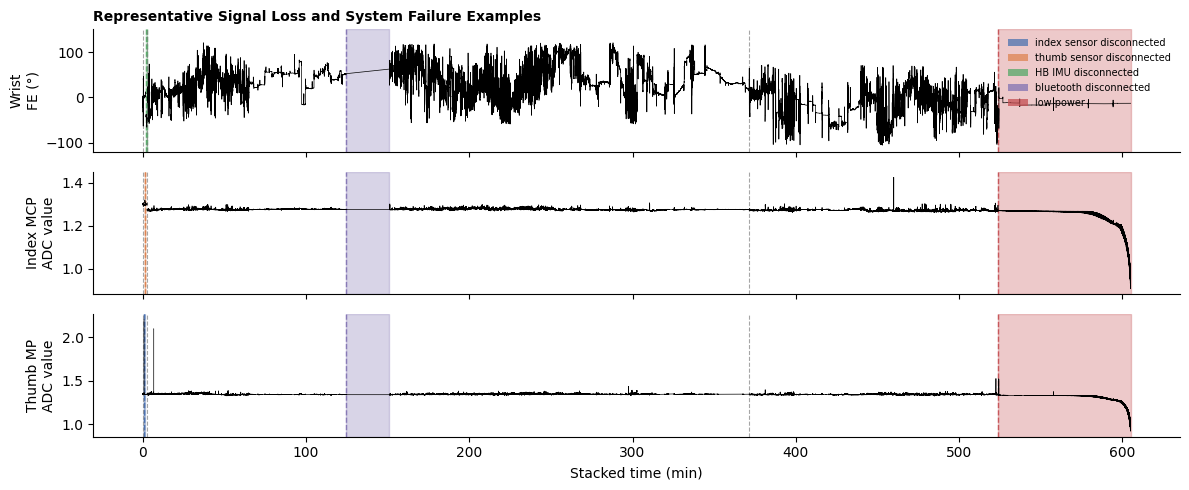

In [960]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

disconnect_display_name_map = {
    "wrist_flex_ext_deg": "Wrist\nFE (°)",
    "ADC_ch0": "Index MCP\nADC value",
    "ADC_ch1": "Thumb MP\nADC value",
}

disconnect_ylim_map = {
    "wrist_flex_ext_deg": (-120, 150),
    "ADC_ch0": None,
    "ADC_ch1": None,
}

disconnect_colors = {
    "index sensor disconnected": "#4C72B0",
    "thumb sensor disconnected": "#DD8452",
    "HB IMU disconnected": "#55A868",
    "bluetooth disconnected": "#8172B2",
    "low power": "#C44E52",
}

plot_cols = [
    "wrist_flex_ext_deg",
    "ADC_ch0",
    "ADC_ch1",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

for ax, col in zip(axes, plot_cols):
    used_labels = set()

    # shading
    for ev in disconnect_events_stacked:
        if col not in ev["signals"]:
            continue

        label = ev["label"]
        color = disconnect_colors.get(label, "lightgray")
        alpha = 0.3 # if label in ["bluetooth down", "battery dying"] else 0.80
        show_label = label if label not in used_labels else None

        ax.axvspan(
            ev["stacked_start_min"],
            ev["stacked_end_min"],
            color=color,
            alpha=alpha,
            zorder=0,
            label=show_label,
        )
        ax.axvline(
            ev["stacked_start_min"],
            color=color,
            linestyle="--",
            linewidth=1.0,
            alpha=0.9,
            zorder=1,
        )
        used_labels.add(label)

    # signal trace
    ax.plot(
        df_disconnect_stacked["elapsed_min_stacked"],
        df_disconnect_stacked[col],
        color="black",
        linewidth=0.5,
        zorder=2,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylabel(disconnect_display_name_map[col])

    if disconnect_ylim_map.get(col) is not None:
        ax.set_ylim(*disconnect_ylim_map[col])

# file boundaries
for ax in axes:
    for _, row in stacked_file_bounds.iterrows():
        ax.axvline(
            row["stacked_start_min"],
            color="gray",
            linestyle="--",
            linewidth=0.8,
            alpha=0.7,
            zorder=1,
        )

# # file labels
# axes[0].text(
#     stacked_file_bounds.loc[0, "stacked_start_min"],
#     1.03,
#     "03/18 disconnect",
#     transform=axes[0].get_xaxis_transform(),
#     ha="left",
#     va="bottom",
#     fontsize=9,
#     fontweight="bold",
# )

# axes[0].text(
#     stacked_file_bounds.loc[1, "stacked_start_min"],
#     1.03,
#     "03/05 6hr",
#     transform=axes[0].get_xaxis_transform(),
#     ha="left",
#     va="bottom",
#     fontsize=9,
#     fontweight="bold",
# )

# axes[0].text(
#     stacked_file_bounds.loc[2, "stacked_start_min"],
#     1.03,
#     "03/05 battery",
#     transform=axes[0].get_xaxis_transform(),
#     ha="left",
#     va="bottom",
#     fontsize=9,
#     fontweight="bold",
# )

legend_handles = [
    Patch(facecolor=disconnect_colors[label], edgecolor="none", alpha=0.75, label=label)
    for label in [
        "index sensor disconnected",
        "thumb sensor disconnected",
        "HB IMU disconnected",
        "bluetooth disconnected",
        "low power",
    ]
]

axes[0].legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=7,
    ncol=1,
)

axes[0].set_title(
    "Representative Signal Loss and System Failure Examples",
    loc="left",
    fontsize=10,
    fontweight="bold",
)

axes[-1].set_xlabel("Stacked time (min)")

plt.tight_layout()
plt.show()

In [979]:
display_windows = [
    {"label": "03/18 disconnect", "start": 0.4,   "end": 2.5,  "display_width": 5.0},
    {"label": "03/05 6hr",        "start": 100.0, "end": 170.0, "display_width": 5.0},
    {"label": "03/05 battery",    "start": 495.0, "end": None,  "display_width": 9.0},
]

In [980]:
def remap_equal_width_windows(
    df_stacked,
    events_stacked,
    *,
    xcol="elapsed_min_stacked",
    windows=None,
    window_width=10.0,
    gap_width=1.5,
):
    """
    Remap selected windows from a continuous stacked timeline into
    equal-width display blocks separated by gaps.

    Returns
    -------
    df_disp : dataframe with new column 'display_x'
    events_disp : list of events with display-space start/end
    window_bounds : DataFrame describing each displayed block
    """
    if windows is None or len(windows) == 0:
        raise ValueError("windows must be a non-empty list")

    df_parts = []
    events_disp = []
    bounds = []

    x_display_start = 0.0
    x_max = float(df_stacked[xcol].dropna().max())

    for i, win in enumerate(windows):
        t0 = float(win["start"])
        t1 = x_max if win["end"] is None else float(win["end"])

        if t1 <= t0:
            continue

        sub = df_stacked[
            (df_stacked[xcol] >= t0) &
            (df_stacked[xcol] <= t1)
        ].copy()

        if sub.empty:
            print(f"Skipping empty window: {win['label']} ({t0} to {t1})")
            continue

        scale = window_width / (t1 - t0)
        sub["display_x"] = x_display_start + (sub[xcol] - t0) * scale
        sub["window_label"] = win["label"]
        sub["window_index"] = i + 1
        df_parts.append(sub)

        x0_disp = x_display_start
        x1_disp = x_display_start + window_width

        bounds.append({
            "window_index": i + 1,
            "label": win["label"],
            "stacked_start": t0,
            "stacked_end": t1,
            "display_start": x0_disp,
            "display_end": x1_disp,
            "scale": scale,
        })

        # remap events that overlap this window
        for ev in events_stacked:
            ev0 = float(ev["stacked_start_min"])
            ev1 = float(ev["stacked_end_min"])

            overlap0 = max(ev0, t0)
            overlap1 = min(ev1, t1)
            if overlap1 <= overlap0:
                continue

            events_disp.append({
                **ev,
                "window_label": win["label"],
                "window_index": i + 1,
                "display_start": x_display_start + (overlap0 - t0) * scale,
                "display_end": x_display_start + (overlap1 - t0) * scale,
            })

        x_display_start = x1_disp + gap_width

    if not df_parts:
        raise ValueError("No data found in any display window.")

    df_disp = pd.concat(df_parts, ignore_index=True, sort=False)
    bounds_df = pd.DataFrame(bounds)

    return df_disp, events_disp, bounds_df

In [981]:
# build stacked raw dataframe
df_disconnect_stacked_raw, stacked_file_bounds = stack_files_continuously(
    [
        disconnect_file_data["raw_df"],
        sixhr_file_data["raw_df"],
        battery_file_data["raw_df"],
    ],
    file_labels=[
        "disconnect_file",
        "sixhr_file",
        "battery_file",
    ],
    time_col="elapsed_min",
    new_time_col="elapsed_min_stacked",
    gap_min=0.05,
    add_nan_separator=True,
)

# compute wrist FE from raw IMUs
df_disconnect_stacked_raw = add_wrist_flex_ext_from_imus(
    df_disconnect_stacked_raw,
    fe_source_col=FE_SOURCE_COL,
    out_col="wrist_flex_ext_deg",
    sign=SIGN,
    zero_baseline=ZERO_BASELINE,
    baseline_window_sec=BASELINE_WINDOW_SEC,
    baseline_stat=BASELINE_STAT,
)

# build stacked IMU2 disconnect mask from the per-file raw masks
imu2_mask_stacked, _ = stack_files_continuously(
    [
        disconnect_file_data["raw_df"].assign(
            imu2_disconnected_mask=disconnect_file_data["imu2_disconnected_mask"].astype(float)
        ),
        sixhr_file_data["raw_df"].assign(
            imu2_disconnected_mask=sixhr_file_data["imu2_disconnected_mask"].astype(float)
        ),
        battery_file_data["raw_df"].assign(
            imu2_disconnected_mask=battery_file_data["imu2_disconnected_mask"].astype(float)
        ),
    ],
    file_labels=[
        "disconnect_file",
        "sixhr_file",
        "battery_file",
    ],
    time_col="elapsed_min",
    new_time_col="elapsed_min_stacked",
    gap_min=0.05,
    add_nan_separator=True,
)

imu2_mask_bool = imu2_mask_stacked["imu2_disconnected_mask"].fillna(0).astype(bool)

# only invalidate wrist FE where IMU2 is disconnected
df_disconnect_stacked_raw.loc[imu2_mask_bool, "wrist_flex_ext_deg"] = np.nan

/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/778747077.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stacked = pd.concat(stacked_parts, ignore_index=True, sort=False)
/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/778747077.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stacked = pd.concat(stacked_parts, ignore_index=True, sort=False)


In [982]:
df_disconnect_stacked_raw = add_wrist_flex_ext_from_imus(
    df_disconnect_stacked_raw,
    fe_source_col=FE_SOURCE_COL,
    out_col="wrist_flex_ext_deg",
    sign=SIGN,
    zero_baseline=ZERO_BASELINE,
    baseline_window_sec=BASELINE_WINDOW_SEC,
    baseline_stat=BASELINE_STAT,
)

def remap_variable_width_windows(
    df_stacked,
    events_stacked,
    *,
    xcol="elapsed_min_stacked",
    windows=None,
    gap_width=1.5,
):
    """
    Remap selected windows from stacked time into display coordinates.

    Each window can have its own display width via:
        window["display_width"]

    Also inserts NaN separator rows between windows so plotted lines do not
    connect across the empty gaps.
    """
    if windows is None or len(windows) == 0:
        raise ValueError("windows must be a non-empty list")

    df_parts = []
    events_disp = []
    bounds = []

    x_display_start = 0.0
    x_max = float(df_stacked[xcol].dropna().max())

    all_cols = list(df_stacked.columns)

    for i, win in enumerate(windows):
        t0 = float(win["start"])
        t1 = x_max if win["end"] is None else float(win["end"])
        display_width = float(win["display_width"])

        if t1 <= t0:
            continue

        sub = df_stacked[
            (df_stacked[xcol] >= t0) &
            (df_stacked[xcol] <= t1)
        ].copy()

        if sub.empty:
            print(f"Skipping empty window: {win['label']} ({t0} to {t1})")
            continue

        scale = display_width / (t1 - t0)
        sub["display_x"] = x_display_start + (sub[xcol] - t0) * scale
        sub["window_label"] = win["label"]
        sub["window_index"] = i + 1
        df_parts.append(sub)

        x0_disp = x_display_start
        x1_disp = x_display_start + display_width

        bounds.append({
            "window_index": i + 1,
            "label": win["label"],
            "stacked_start": t0,
            "stacked_end": t1,
            "display_start": x0_disp,
            "display_end": x1_disp,
            "display_width": display_width,
            "scale": scale,
        })

        for ev in events_stacked:
            ev0 = float(ev["stacked_start_min"])
            ev1 = float(ev["stacked_end_min"])

            overlap0 = max(ev0, t0)
            overlap1 = min(ev1, t1)
            if overlap1 <= overlap0:
                continue

            events_disp.append({
                **ev,
                "window_label": win["label"],
                "window_index": i + 1,
                "display_start": x_display_start + (overlap0 - t0) * scale,
                "display_end": x_display_start + (overlap1 - t0) * scale,
            })

        # insert separator row so lines do NOT connect across the gap
        if i < len(windows) - 1:
            sep = {c: np.nan for c in all_cols}
            sep["display_x"] = x1_disp + gap_width / 2.0
            sep["window_label"] = np.nan
            sep["window_index"] = np.nan
            df_parts.append(pd.DataFrame([sep]))

        x_display_start = x1_disp + gap_width

    if not df_parts:
        raise ValueError("No data found in any display window.")

    df_disp = pd.concat(df_parts, ignore_index=True, sort=False)
    bounds_df = pd.DataFrame(bounds)

    return df_disp, events_disp, bounds_df

In [983]:
df_disconnect_display, disconnect_events_display, display_window_bounds = remap_variable_width_windows(
    df_disconnect_stacked_raw,
    disconnect_events_stacked,
    xcol="elapsed_min_stacked",
    windows=display_windows,
    gap_width=1.6,
)

/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_39733/3174346749.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_disp = pd.concat(df_parts, ignore_index=True, sort=False)


In [990]:
# make a plotting copy so we can blank traces only for display
df_disconnect_display_plot = df_disconnect_display.copy()

# helper: blank selected columns over displayed event spans
def blank_columns_during_events(df, events, label, columns, xcol="display_x"):
    for ev in events:
        if ev["label"] != label:
            continue

        mask = (
            (df[xcol] >= ev["display_start"]) &
            (df[xcol] <= ev["display_end"])
        )
        for col in columns:
            if col in df.columns:
                df.loc[mask, col] = np.nan

# blank wrist FE during HB IMU disconnect
blank_columns_during_events(
    df_disconnect_display_plot,
    disconnect_events_display,
    label="HB IMU disconnected",
    columns=["wrist_flex_ext_deg"],
)

# blank all traces during bluetooth disconnect
blank_columns_during_events(
    df_disconnect_display_plot,
    disconnect_events_display,
    label="bluetooth disconnected",
    columns=["wrist_flex_ext_deg", "ADC_ch0", "ADC_ch1"],
)

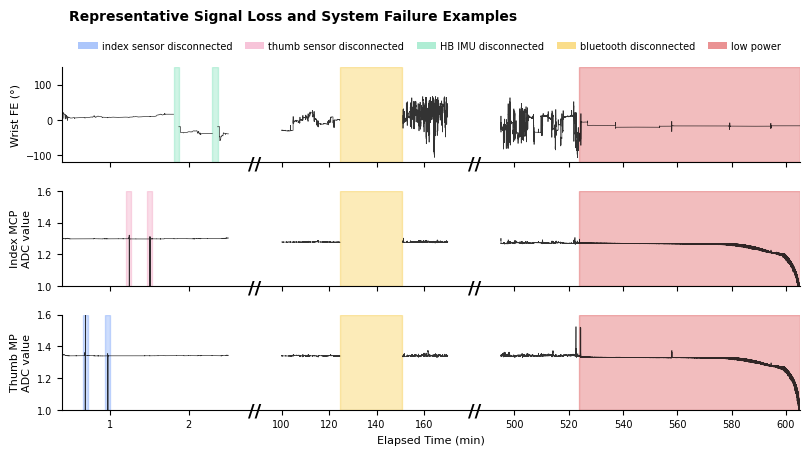

In [1010]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

plot_cols = [
    "wrist_flex_ext_deg",
    "ADC_ch0",
    "ADC_ch1",
]

disconnect_display_name_map = {
    "wrist_flex_ext_deg": "Wrist FE (°)",
    "ADC_ch0": "Index MCP\nADC value",
    "ADC_ch1": "Thumb MP\nADC value",
}

disconnect_ylim_map = {
    "wrist_flex_ext_deg": (-120, 150),
    "ADC_ch0": (1.0, 1.6),
    "ADC_ch1": (1.0, 1.6),
}

disconnect_colors = {
    "index sensor disconnected": label_colors["walking"],
    "thumb sensor disconnected": label_colors["texting"],
    "HB IMU disconnected": label_colors["typing"],
    "bluetooth disconnected": label_colors["eating"],
    "low power": "#D62728",
}

fig, axes = plt.subplots(3, 1, figsize=(8.2, 4.6), sharex=True)

for ax, col in zip(axes, plot_cols):
    used_labels = set()

    # shading
    for ev in disconnect_events_display:
        if col not in ev["signals"]:
            continue

        label = ev["label"]
        color = disconnect_colors.get(label, "lightgray")
        alpha = 0.3
        show_label = label if label not in used_labels else None

        ax.axvspan(
            ev["display_start"],
            ev["display_end"],
            color=color,
            alpha=alpha,
            zorder=0,
            label=show_label,
        )
        used_labels.add(label)

    # trace from masked plotting copy
    ax.plot(
        df_disconnect_display_plot["display_x"],
        df_disconnect_display_plot[col],
        color="black",
        alpha=0.8,
        linewidth=0.5,
        zorder=2,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel(disconnect_display_name_map[col], fontsize=8)
    ax.tick_params(axis="both", labelsize=7)

    if disconnect_ylim_map.get(col) is not None:
        ax.set_ylim(*disconnect_ylim_map[col])

    ax.margins(x=0)

# add // between blocks
for ax in axes:
    for i in range(len(display_window_bounds) - 1):
        x_break = 0.5 * (
            display_window_bounds.iloc[i]["display_end"] +
            display_window_bounds.iloc[i + 1]["display_start"]
        )
        ax.text(
            x_break,
            0.08,
            "//",
            ha="center",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=13,
            fontweight="bold",
            clip_on=False,
            zorder=5,
        )

# custom x ticks: each block shows its own local stacked-time range
xticks = []
xticklabels = []

for _, row in display_window_bounds.iterrows():
    t0 = row["stacked_start"]
    t1 = row["stacked_end"]
    x0 = row["display_start"]
    scale = row["scale"]

    width_real = t1 - t0
    if width_real <= 5:
        tick_step = 1
    elif width_real <= 40:
        tick_step = 10
    else:
        tick_step = 20

    tick_vals = np.arange(np.ceil(t0 / tick_step) * tick_step, t1 + 1e-9, tick_step)
    tick_pos = x0 + (tick_vals - t0) * scale

    xticks.extend(tick_pos.tolist())
    xticklabels.extend([
        f"{int(tv)}" if abs(tv - round(tv)) < 1e-9 else f"{tv:.1f}"
        for tv in tick_vals
    ])

axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels(xticklabels)
axes[-1].set_xlabel("Elapsed Time (min)", fontsize=8)

for ax in axes:
    ax.set_xlim(
        df_disconnect_display["display_x"].min(),
        df_disconnect_display["display_x"].max()
    )

legend_handles = [
    Patch(facecolor=disconnect_colors["index sensor disconnected"], edgecolor="none", alpha=0.5, label="index sensor disconnected"),
    Patch(facecolor=disconnect_colors["thumb sensor disconnected"], edgecolor="none", alpha=0.5, label="thumb sensor disconnected"),
    Patch(facecolor=disconnect_colors["HB IMU disconnected"], edgecolor="none", alpha=0.5, label="HB IMU disconnected"),
    Patch(facecolor=disconnect_colors["bluetooth disconnected"], edgecolor="none", alpha=0.5, label="bluetooth disconnected"),
    Patch(facecolor=disconnect_colors["low power"], edgecolor="none", alpha=0.5, label="low power"),
]

# title at top
fig.suptitle(
    "Representative Signal Loss and System Failure Examples",
    x=0.09,   # left-ish alignment
    y=0.98,
    ha="left",
    fontsize=10,
    fontweight="bold",
)

# legend under title, above plots, no frame
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.93),
    frameon=False,
    fontsize=7,
    ncol=5,
    columnspacing=1.3,
    handletextpad=0.4,
    labelspacing=0.35,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("disconnect_examples_figure.pdf", bbox_inches="tight")
plt.show()